<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Monte_Carlo_Prediction_of_Single_Atom_Transistor_Scale_Up_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python -m pip -q install uv
!uv pip install --system "cupy-cuda12x[ctk]" numpy scipy matplotlib

GPU: NVIDIA L4; CuPy 14.0.1
Sampler checks passed: Poisson, Gaussian, complete nominal gates.
Sampling STM reference: 8,388,608 site trials...
Sampling Neutral donor delivery: 8,388,608 site trials...
Sampling Matter-wave + chemistry: 8,388,608 site trials...
Sampling Matter-wave + STM: 8,388,608 site trials...

ASSUMPTION-DRIVEN RESULTS; acceptance proxy, not transport certification
Lateral radius 1 nm; depth tolerance +/-0.5 nm. Strict radius 0.2 nm is NOT lattice-site certification.
Route                        Yield % [5,50,95]          Pooled good/h  Strict yield %
STM reference                51.352, 65.988, 78.270            659.04          48.647
Neutral donor delivery       0.031, 0.259, 2.123               162.02           0.024
Matter-wave + chemistry      0.351, 2.512, 12.373             1182.00           0.200
Matter-wave + STM            38.745, 54.739, 66.306           1416.14          39.414

Nominal hybrid break-even STM finish time: 1.707 s/site.
Hybrid is faster only

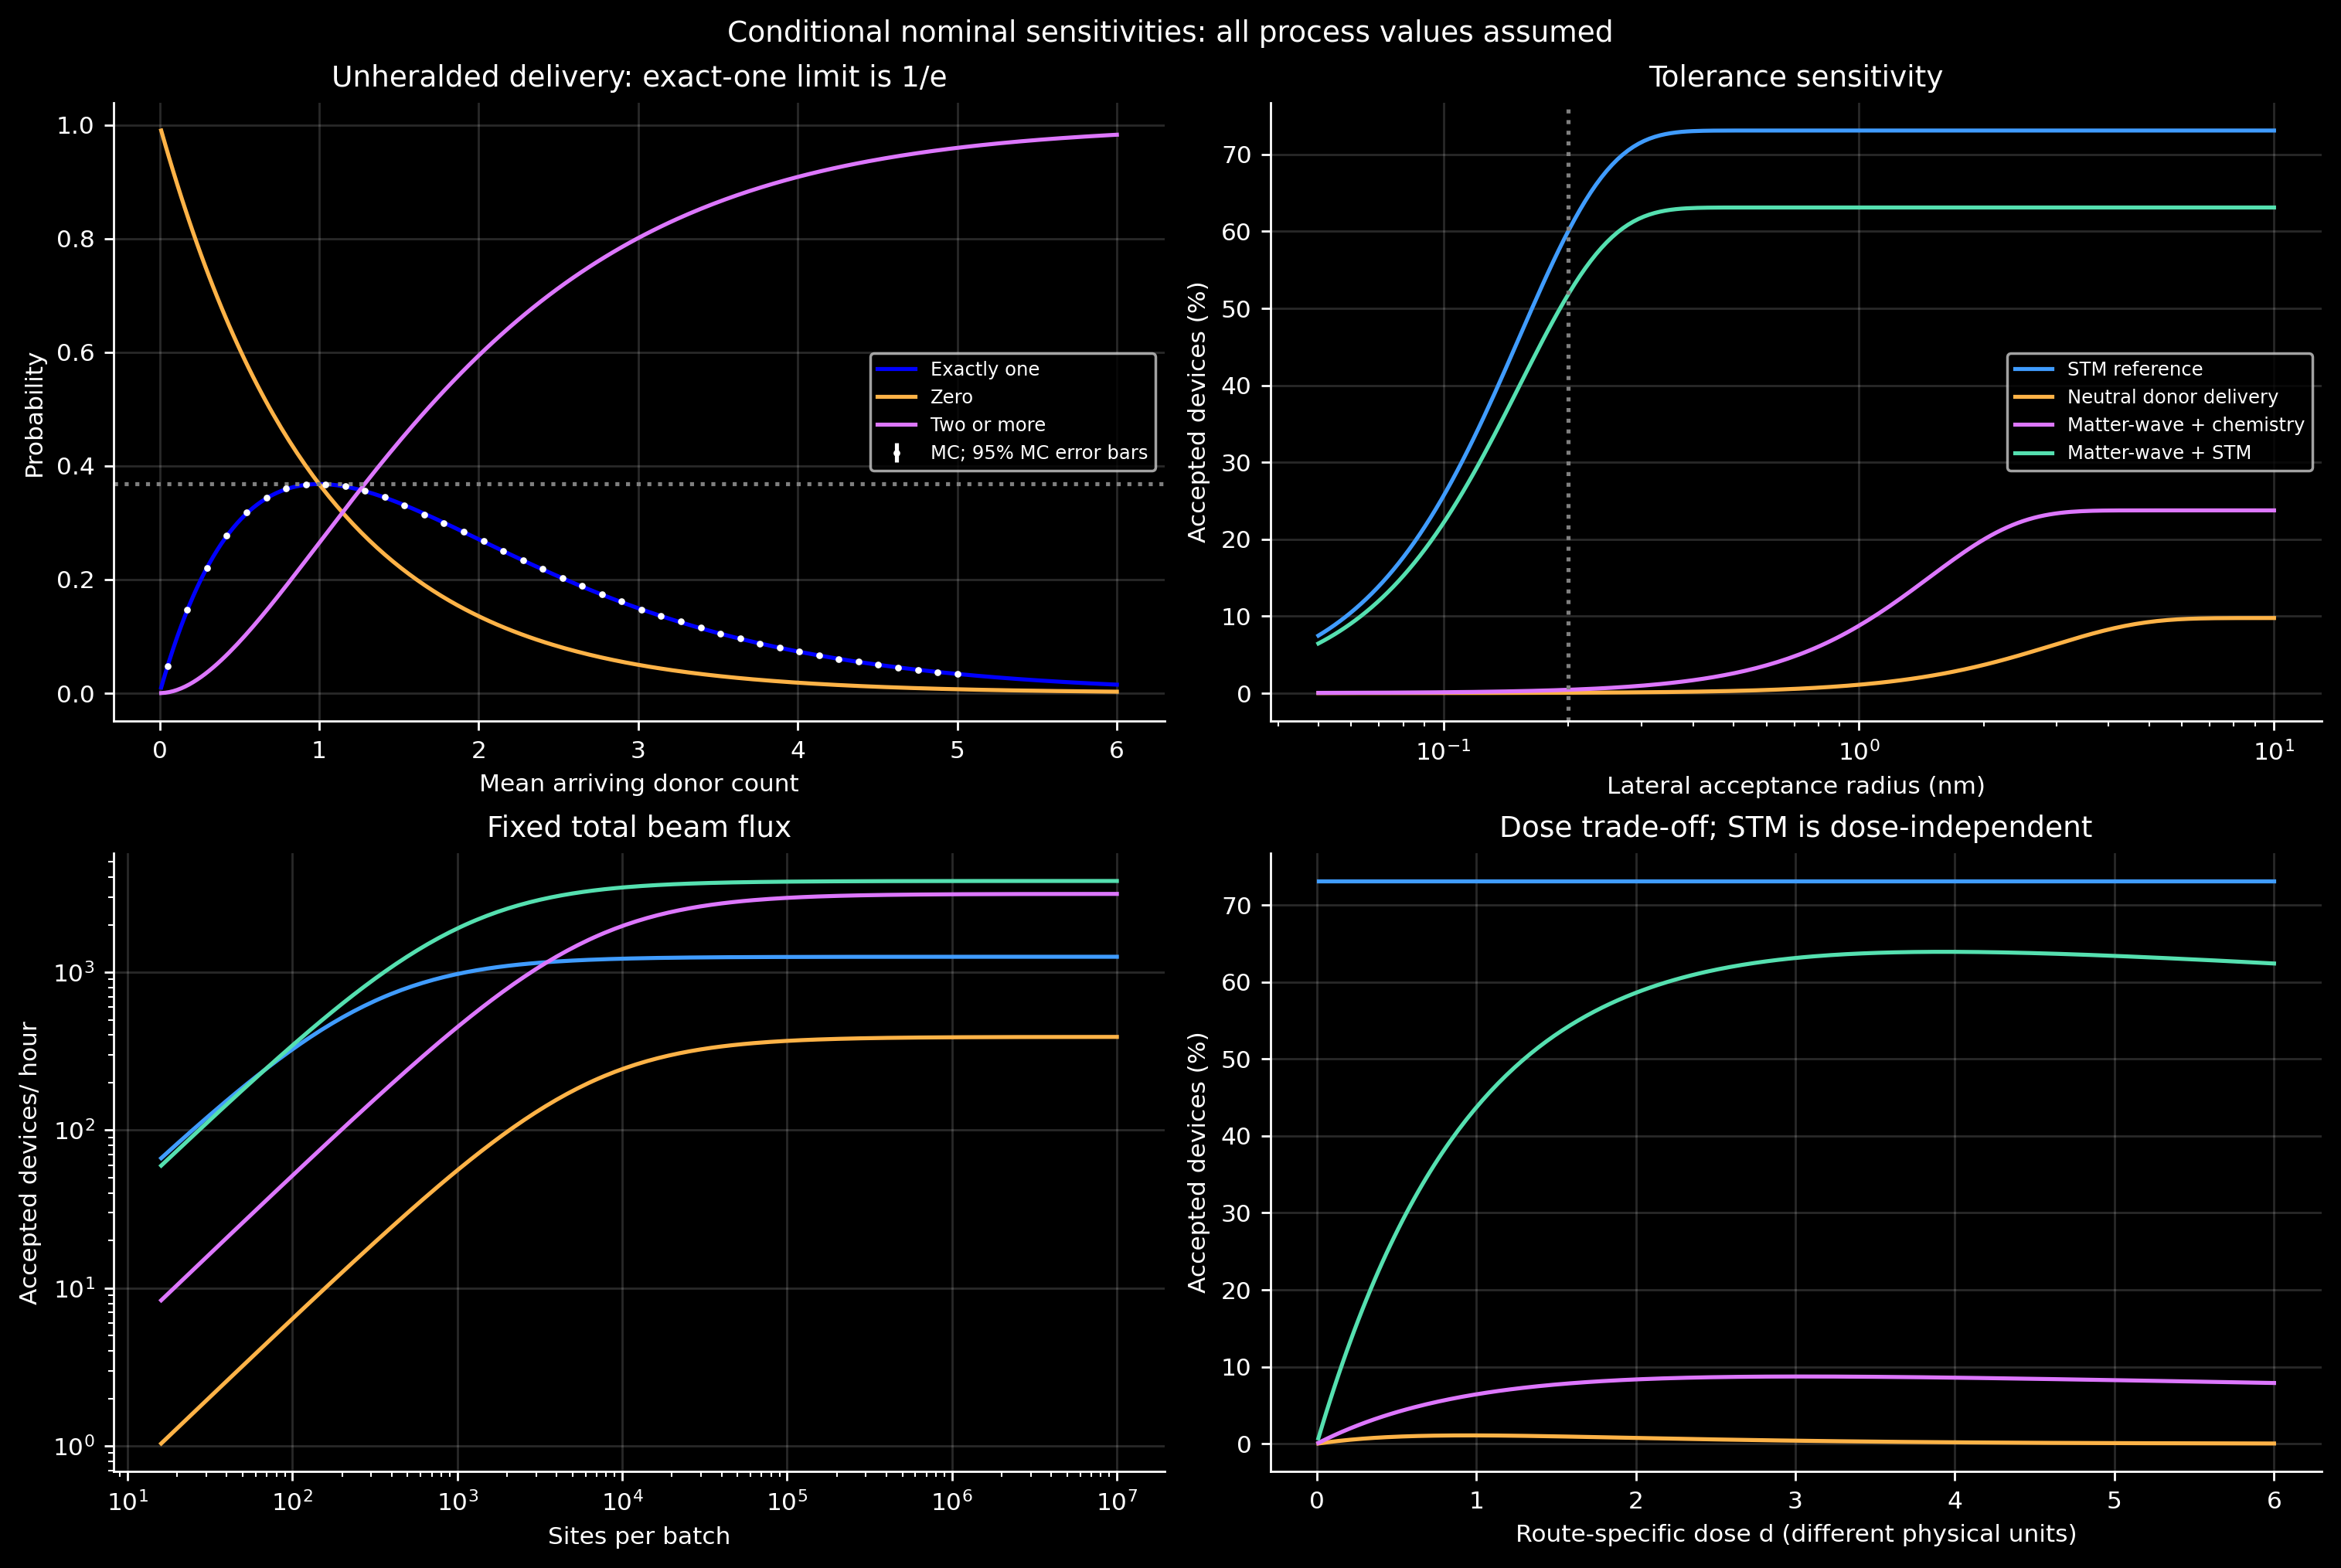

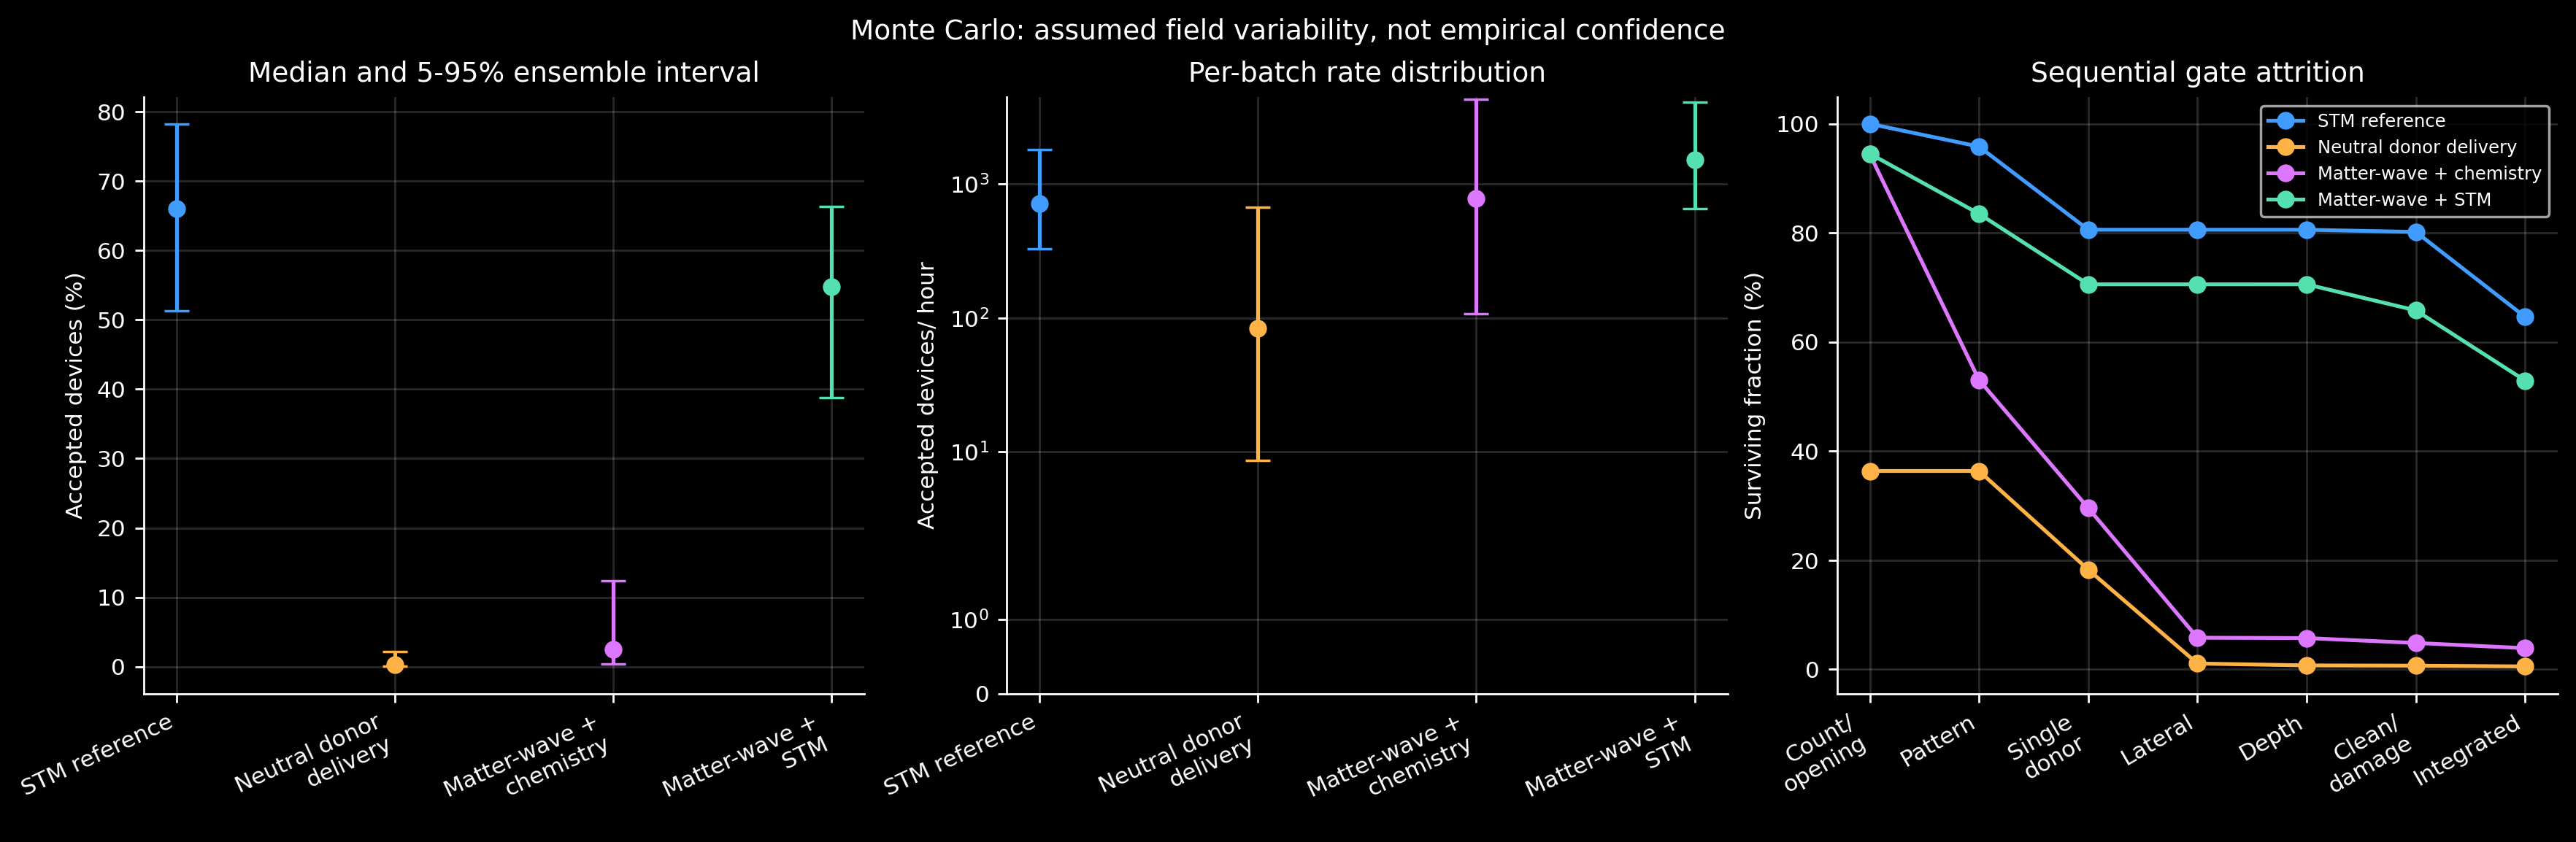

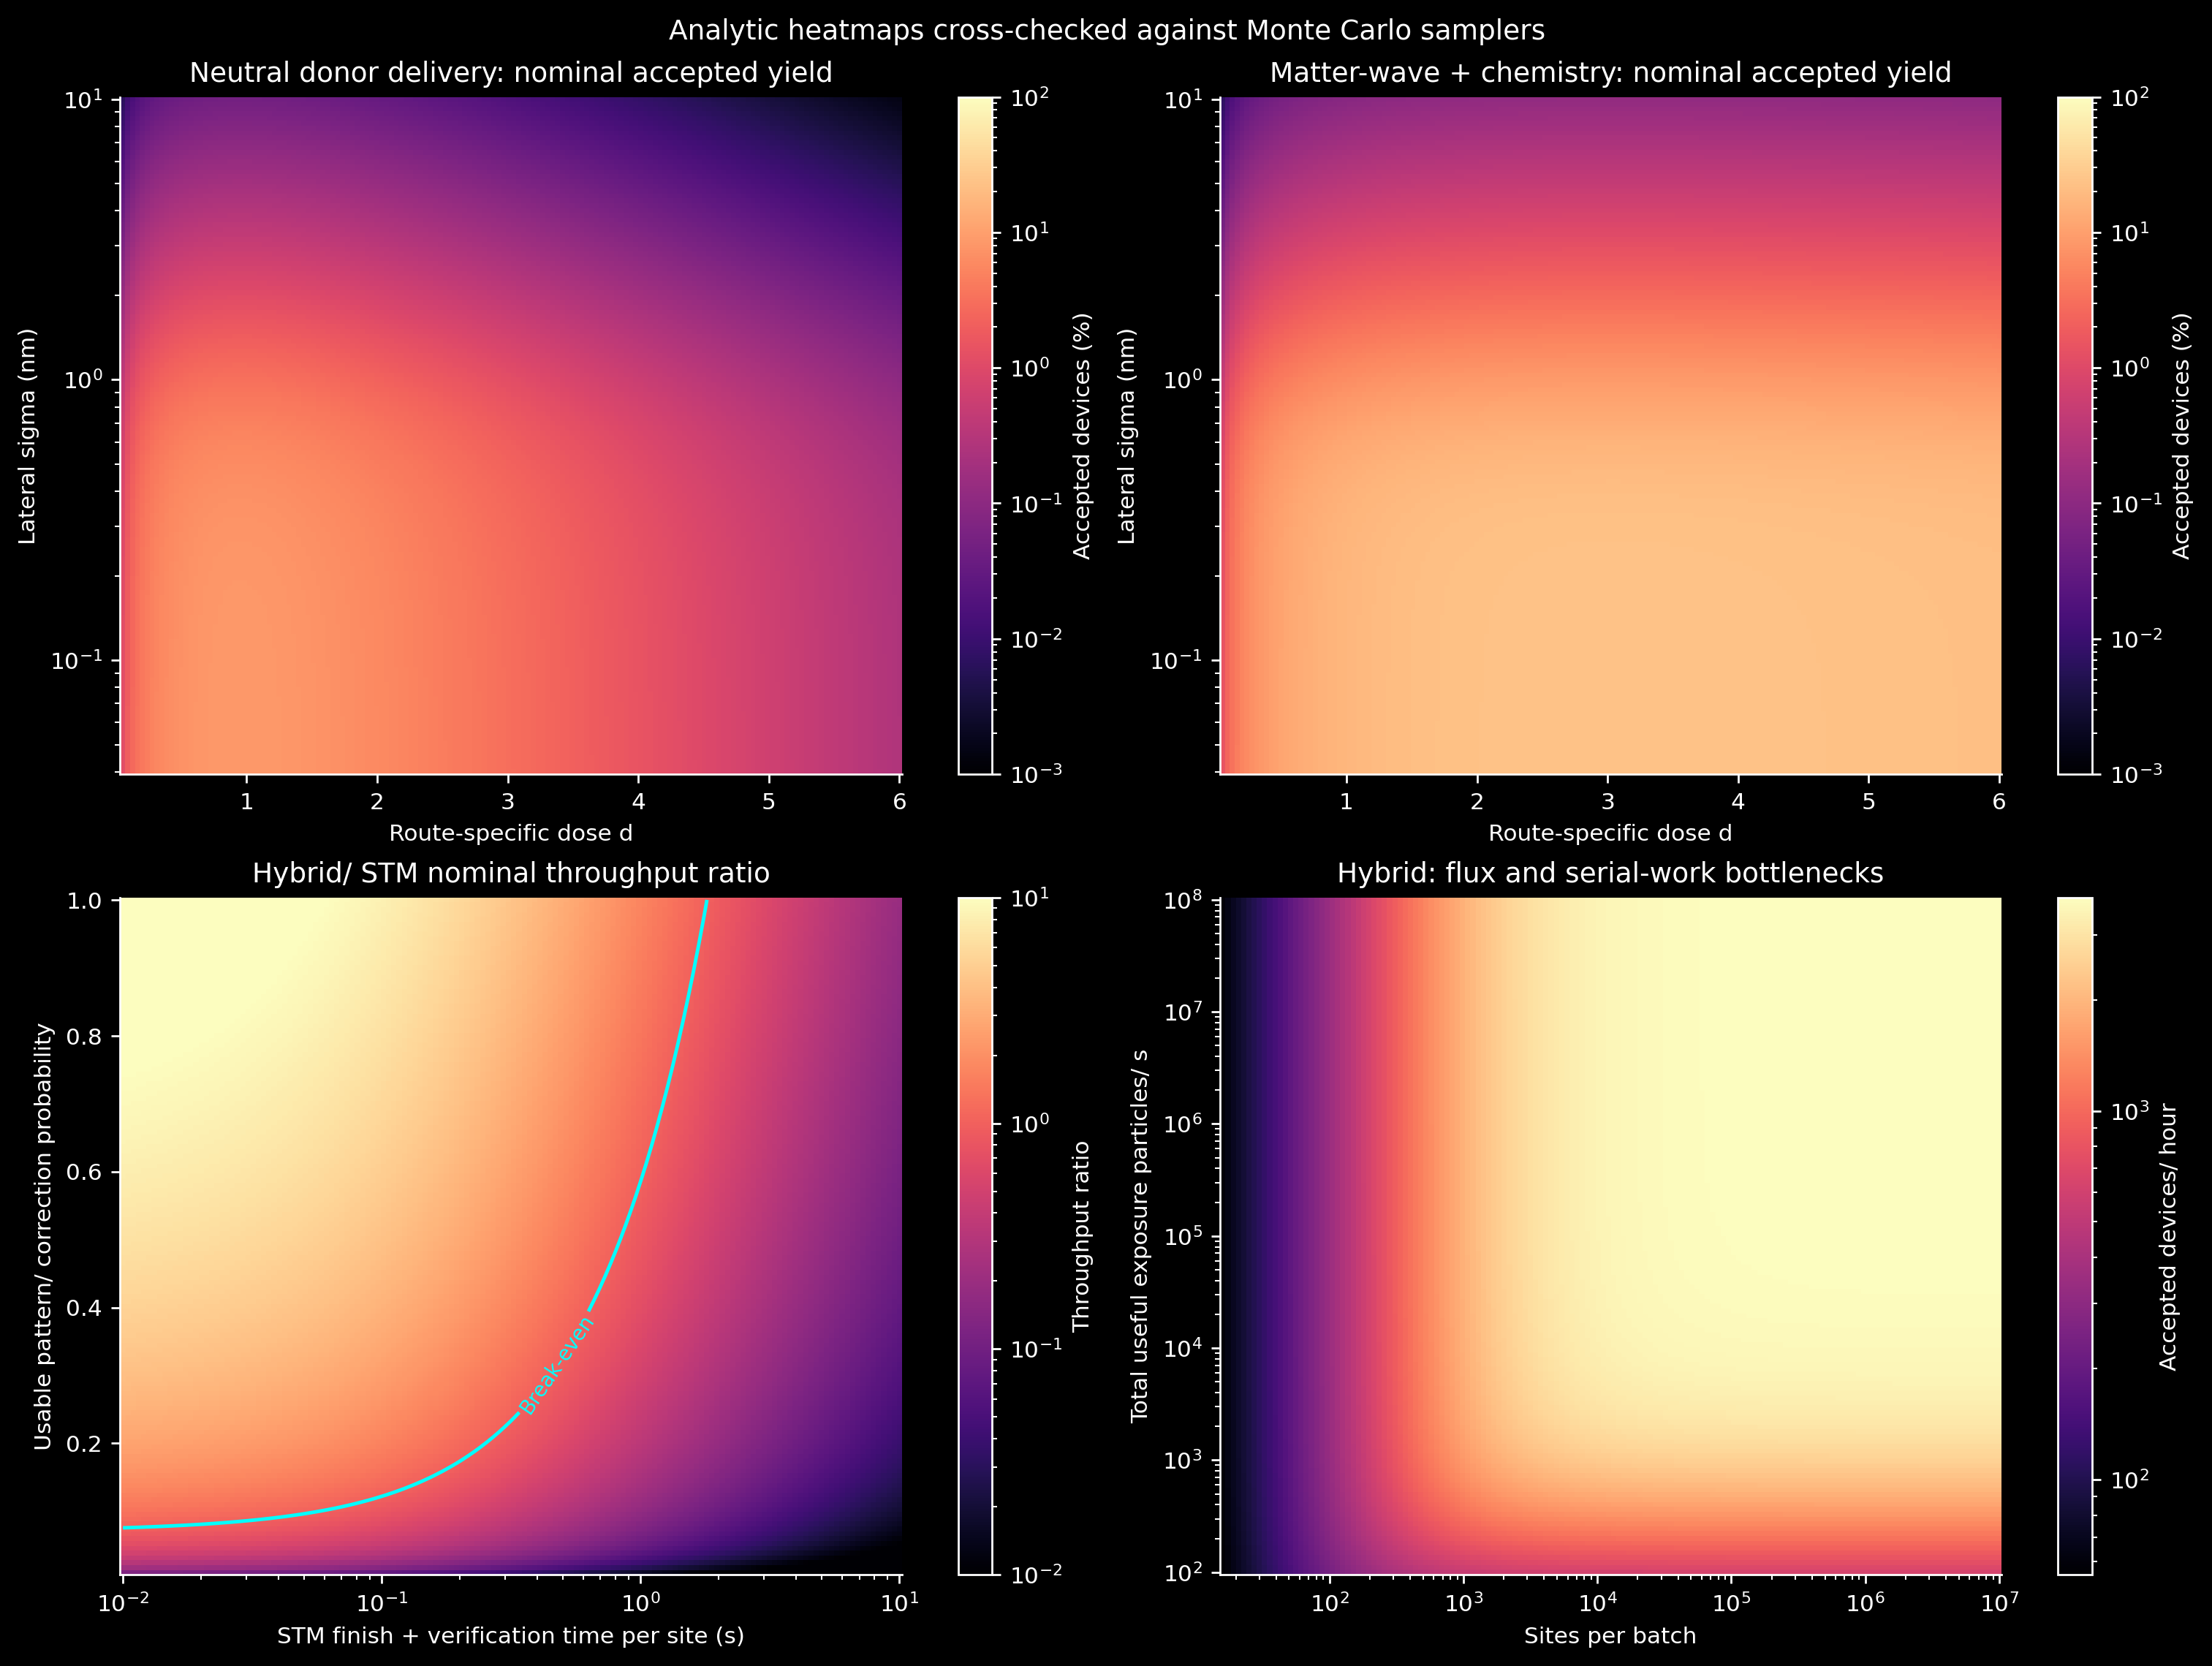

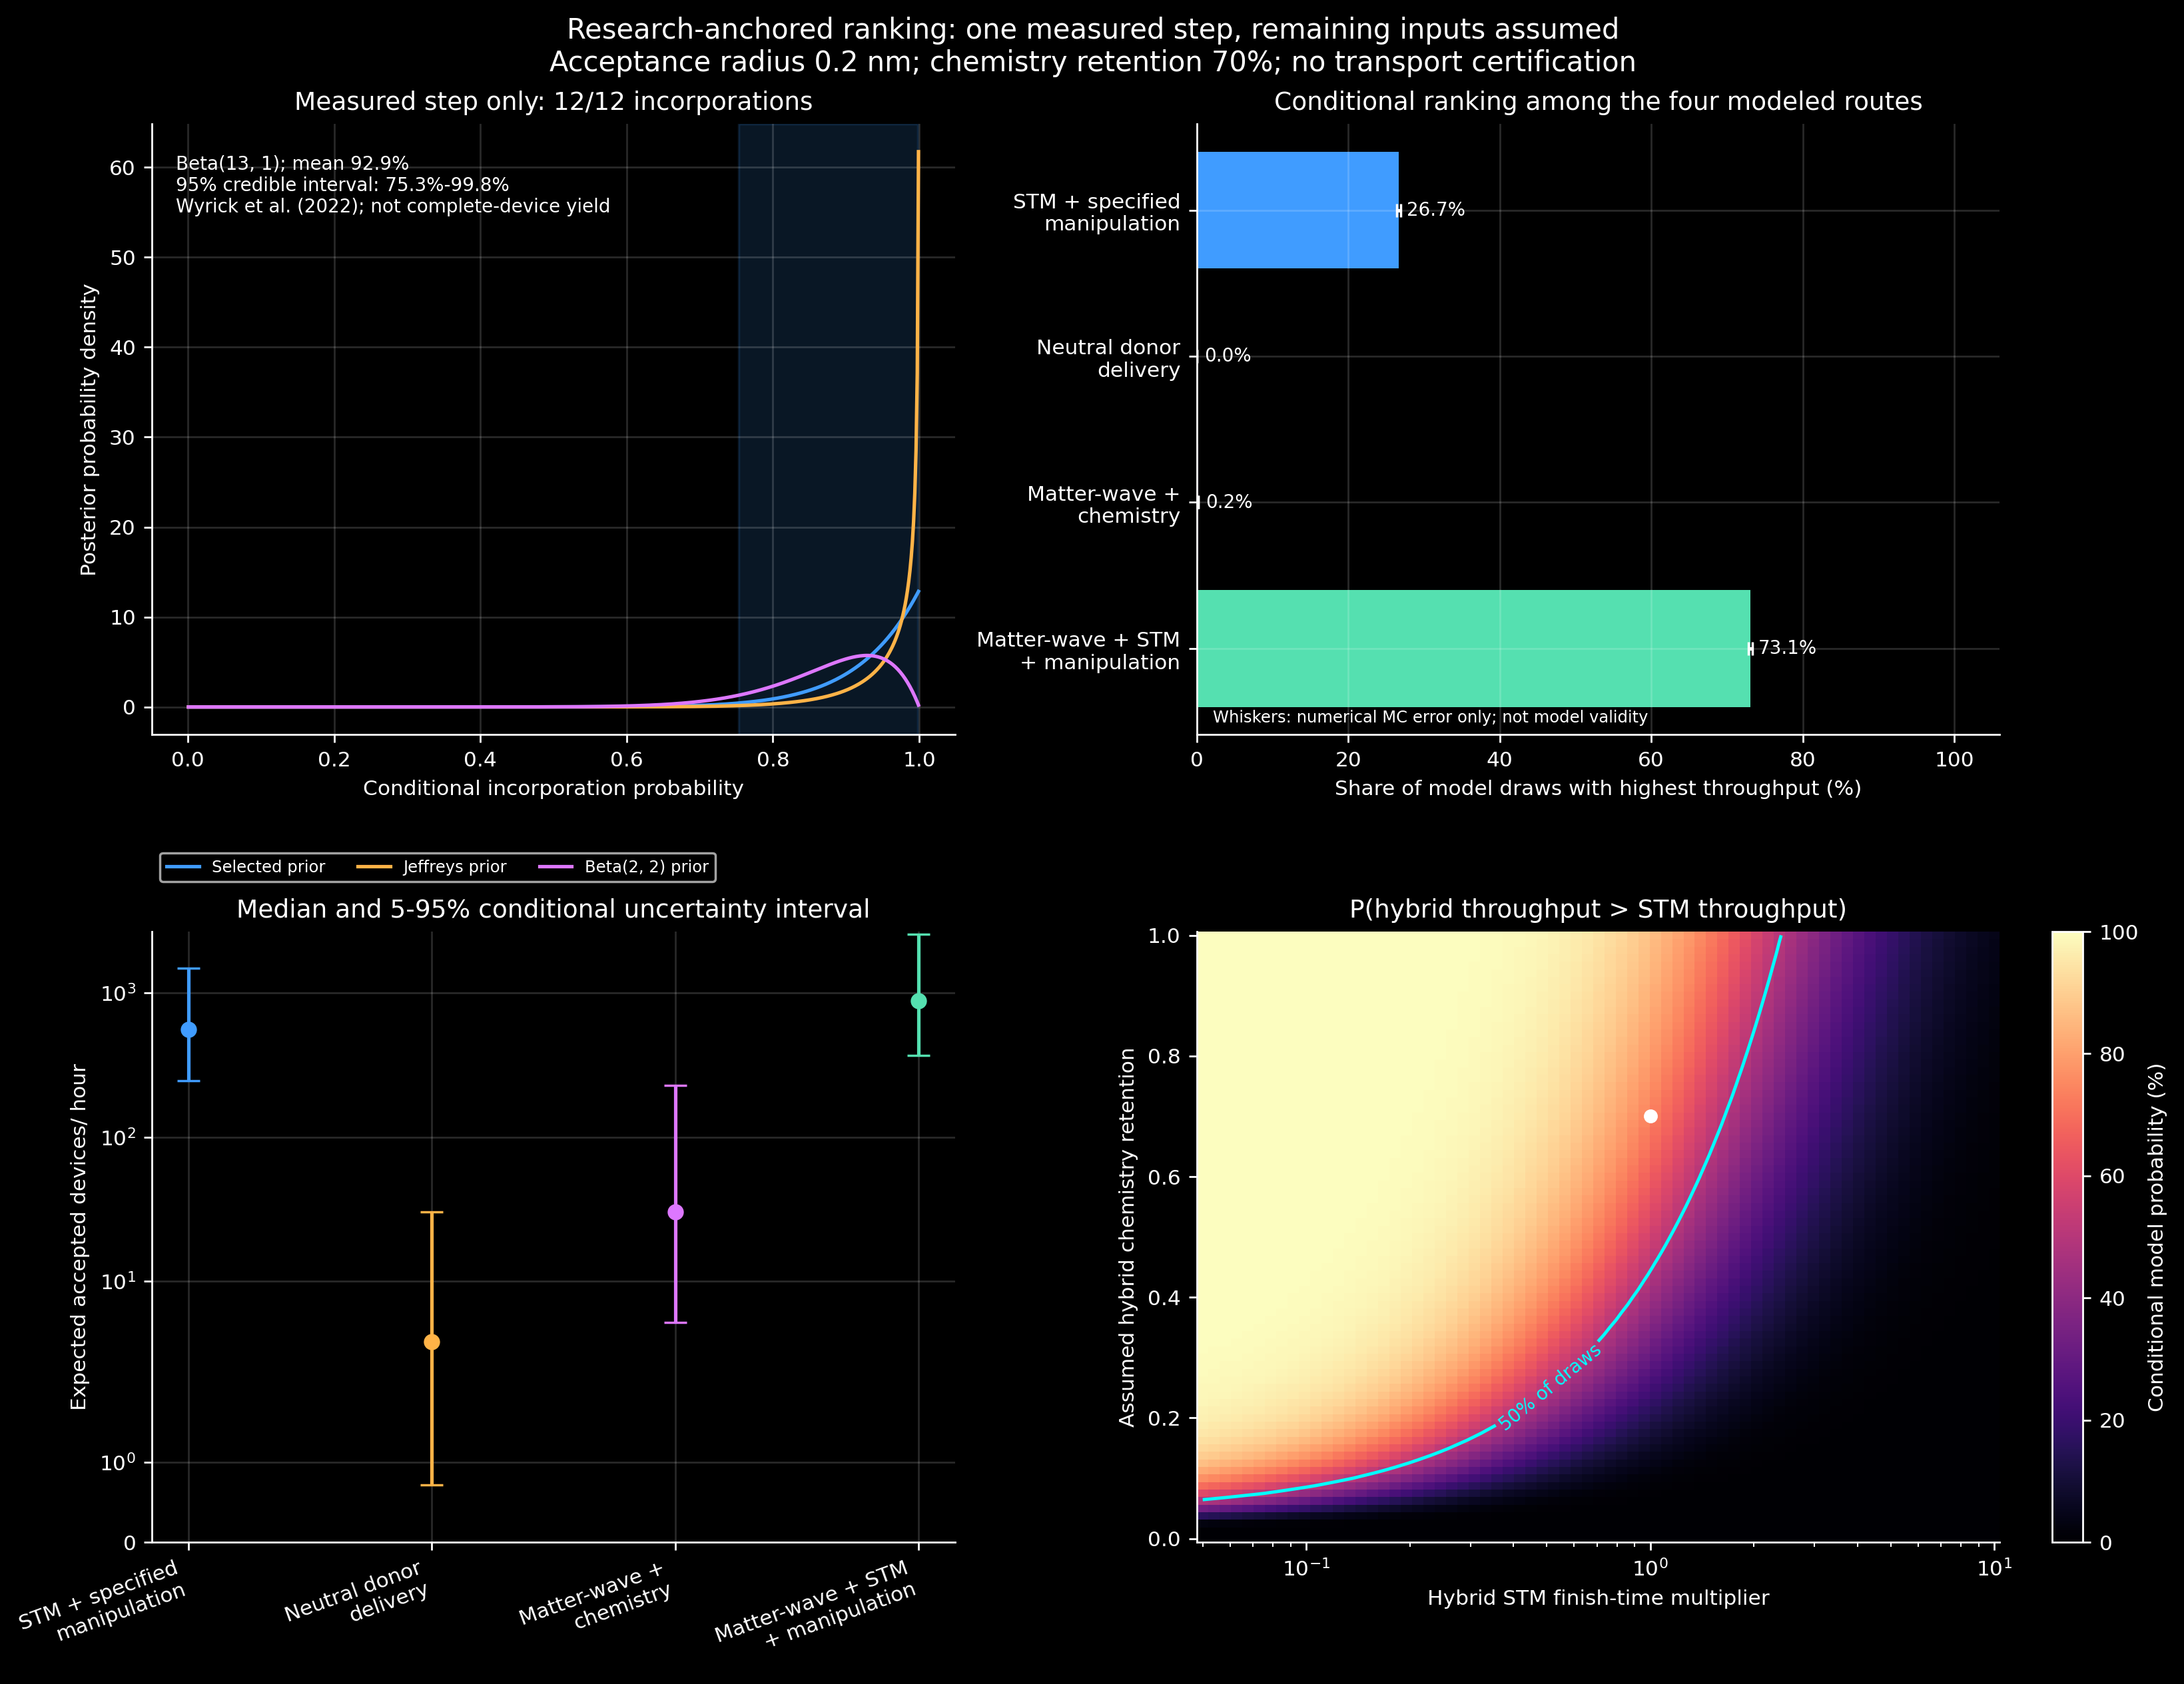


RESEARCH-ANCHORED, ASSUMPTION-CONDITIONAL RANKING
Data: 12/12 selected STM incorporation attempts; all rate inputs assumed.
No directly comparable full-route manufacturing dataset was used.
STM has the strongest direct single-donor device evidence in this set.
Highest probability of model rank 1: Matter-wave + STM + manipulation
STM + specified manipulation          rank-1 share= 26.68%; median accepted/hour=559.10
Neutral donor delivery                rank-1 share=  0.00%; median accepted/hour=3.79
Matter-wave + chemistry               rank-1 share=  0.21%; median accepted/hour=30.16
Matter-wave + STM + manipulation      rank-1 share= 73.11%; median accepted/hour=882.11
Rank-1 shares are not experimental probabilities of feasibility.
Shared incorporation evidence cancels in the hybrid/STM rate ratio;
their ordering is driven by the stated timing and transfer assumptions.
The 12/12 result is not assigned to direct neutral or resist chemistry.
EUV H desorption is an experimentally supp

In [6]:
"""This script compares conditional single-donor fabrication yield and throughput on a GPU.

Scientific scope:
    This is a conditional engineering Monte Carlo model, not a calibrated
    forecast or a quantum transport solver. All numerical process parameters
    below are ASSUMPTIONS, not measured neutral-beam single-transistor yields.
    Figure 04 separately updates a specified STM incorporation step with the
    published 12/12 count; all other ranking inputs remain assumptions.
    Successful devices satisfy an engineering acceptance proxy: one donor,
    lateral/depth tolerances, no parasitic donor, and a final integration gate.
    That proxy does not prove transistor operation or crystallographic registry.
    The model does not solve surface chemistry, hydrogen desorption, atom optics,
    wave propagation, substitutional energetics, or source/drain tunnel rates.

Routes:
    STM: atomic patterning, precursor dosing and donor incorporation.
    Neutral donor: unheralded neutral phosphorus delivery with Poisson counts.
    Matter-wave + chemistry: hypothetical parallel resist windows followed by
        selective donor chemistry. Exposure particles are NOT phosphorus donors.
    Matter-wave + STM: hypothetical coarse parallel patterning followed by STM
        refinement/verification at EVERY donor site, then donor chemistry.
        Compatibility with clean H-Si surfaces remains an experimental question.

Probability model:
    Unheralded direct donor count: P(N=1) = d*exp(-d), at most 1/e.
    Resist opening: P(open) = 1-exp(-d), a phenomenological response law.
    Resist route exact-one incorporation is a separate probability q_single.
    Parasitic active donors are Poisson with mean b; P(clean)=exp(-b).
    Centered lateral Gaussian acceptance is 1-exp(-r**2/(2*sigma**2)).
    Centered depth acceptance is erf(z_tol/(sqrt(2)*sigma_z)).
    The hybrid assumes STM resets local lateral error to its refinement floor;
    unsuccessful correction is absorbed into q_pattern, not hidden as certainty.

Time model (non-overlapped, end-to-end batch cycle):
    t = batch_overhead + N/backend_rate + parallel_exposure + N*serial_time.
    Parallel_exposure = N*d*particles_per_dose/usable_flux.
    Flux is TOTAL useful particle rate across the field, not rate per site.
    Backend rate represents leads, gates, encapsulation, contacts and test.
    No extra throughput credit is given for spatial parallelism at fixed flux.

Monte Carlo:
    Outer draws are assumed field-to-field variability and scenario uncertainty,
    not a posterior learned from data. Shared dose, registration, process yields,
    backend speed and catastrophic field defects correlate devices in a field.
    Inner draws sample actual site outcomes on the GPU in bounded field batches.
    Bands describe this stipulated ensemble; binomial MC error is kept separate.
    Metropolis sampling is unnecessary because all distributions sample directly.

Primary references (mechanism anchors, not calibration of numerical defaults):
    Fuechsle et al. (2012), doi:10.1038/nnano.2012.21.
        Deterministically positioned single-P transistor using STM H lithography.
    Wyrick et al. (2022), doi:10.1021/acsnano.2c08162.
        Engineered dangling-bond chemistry; 12/12 incorporation after specific
        STM manipulation is a small experiment, not a general 100% yield claim.
    Nesse et al. (2019), doi:10.1103/PhysRevApplied.11.024009.
        Matter-wave binary holography pattern calculations, not demonstrated
        mass production of single-donor transistors.
    Fiedler et al. (2023), doi:10.1088/2632-2153/acd988.
        Atom-mask interactions complicate matter-wave mask design.

Figures render in memory at 250 DPI, with optional local export. Runtime depends
on the Colab environment; defaults simulate about 34 million site-route trials.
"""

import io
import json
from pathlib import Path
import time

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.special import erf

# - Control knobs: execution and plotting -
USE_GPU = True
SEED = 20260924
N_FIELDS = 512
SITES_PER_FIELD = 16384
FIELDS_PER_BATCH = 8
VALIDATION_TRIALS = 200000
DPI = 250
SHOW_PLOTS = True
SAVE_OUTPUTS = False
OUTPUT_DIRECTORY = "single_atom_results"
CONTOUR_LABEL_FONTSIZE = 8
CONTOUR_INLINE_SPACING = 5

# - Control knobs: engineering acceptance, not a crystal-lattice model -
LATERAL_TOLERANCE_NM = 1.0
DEPTH_TOLERANCE_NM = 0.5
STRICT_LATERAL_TOLERANCE_NM = 0.2

# - Control knobs: common process assumptions -
# Triples are triangular (minimum, mode, maximum), with no data-based posterior.
INTEGRATION_YIELD = (0.65, 0.85, 0.97)
BACKEND_DEVICES_PER_SECOND = (3.0, 10.0, 30.0)
BATCH_OVERHEAD_SECONDS = 600.0
FIELD_SURVIVAL_PROBABILITY = 0.98
DOSE_COEFFICIENT_OF_VARIATION = 0.15

# - Control knobs: route assumptions -
# sigma_nm is per-axis effective random lateral error, including diffusion.
# registration_nm is a shared per-axis field offset; sigma_z_nm is depth error.
# q_single is exact-one substitutional incorporation, not merely adsorption.
# For direct delivery it is conditional on exactly one arriving donor.
# b0 and b_slope parameterize active parasitic donors in a device exclusion zone.
# No extra factor is applied for the same incorporation event twice.
ROUTES = {
    "STM reference": {
        "kind": "stm",
        "dose": 1.0,
        "sigma_nm": (0.04, 0.10, 0.20),
        "registration_nm": 0.04,
        "sigma_z_nm": 0.12,
        "q_single": (0.65, 0.90, 0.98),
        "q_pattern": (0.90, 0.98, 1.0),
        "b0": 0.005,
        "b_slope": 0.0,
        "damage_per_dose": 0.0,
        "serial_seconds": (0.5, 2.0, 8.0),
        "flux_per_second": (1.0, 1.0, 1.0),
        "particles_per_dose": 0.0,
    },
    "Neutral donor delivery": {
        "kind": "direct",
        "dose": 1.0,
        "sigma_nm": (0.5, 2.0, 10.0),
        "registration_nm": 0.5,
        "sigma_z_nm": 0.5,
        "q_single": (0.15, 0.50, 0.85),
        "q_pattern": (1.0, 1.0, 1.0),
        "b0": 0.02,
        "b_slope": 0.03,
        "damage_per_dose": 0.02,
        "serial_seconds": (0.0, 0.0, 0.0),
        "flux_per_second": (1e3, 1e5, 1e6),
        "particles_per_dose": 1.0,
    },
    "Matter-wave + chemistry": {
        "kind": "resist",
        "dose": 3.0,
        "sigma_nm": (0.3, 1.0, 5.0),
        "registration_nm": 0.3,
        "sigma_z_nm": 0.2,
        "q_single": (0.15, 0.60, 0.90),
        "q_pattern": (0.15, 0.60, 0.95),
        "b0": 0.02,
        "b_slope": 0.03,
        "damage_per_dose": 0.02,
        "serial_seconds": (0.0, 0.0, 0.0),
        "flux_per_second": (1e4, 1e6, 1e7),
        "particles_per_dose": 100.0,
    },
    "Matter-wave + STM": {
        "kind": "hybrid",
        "dose": 3.0,
        "sigma_nm": (0.04, 0.10, 0.20),
        "registration_nm": 0.04,
        "sigma_z_nm": 0.12,
        "q_single": (0.65, 0.90, 0.98),
        "q_pattern": (0.70, 0.95, 0.99),
        "b0": 0.01,
        "b_slope": 0.01,
        "damage_per_dose": 0.01,
        "serial_seconds": (0.1, 0.5, 3.0),
        "flux_per_second": (1e4, 1e6, 1e7),
        "particles_per_dose": 100.0,
    },
}

# - Control knobs: research-anchored ranking -
# This extension ranks four specified scenarios, not all possible technologies.
RANK_DRAWS = 100000
RANK_RADIUS_NM = STRICT_LATERAL_TOLERANCE_NM
RANK_BETA_PRIOR = (1.0, 1.0)
RANK_INCORPORATION_SUCCESSES = 12
RANK_INCORPORATION_ATTEMPTS = 12
# Optional power-likelihood discount for dependence/ limited transferability.
# One uses all 12 counts; zero uses only the prior. Neither adjusts publication
# selection bias. The binomial model assumes exchangeable independent attempts.
RANK_LIKELIHOOD_WEIGHT = 1.0
# Unmeasured chemistry retention after the proposed matter-wave process.
# This multiplies the shared incorporation posterior only. q_pattern already
# represents upstream pattern/refinement success; this is a distinct penalty.
RANK_HYBRID_CHEMISTRY_RETENTION = 0.70
RANK_TRANSFER_GRID = np.linspace(0.0, 1.0, 81)
RANK_FINISH_MULTIPLIERS = np.geomspace(0.05, 10.0, 71)

RESEARCH_EVIDENCE = {
    "accessed": "2026-09-24",
    "incorporation_count": {
        "doi": "10.1021/acsnano.2c08162",
        "url": "https://pubmed.ncbi.nlm.nih.gov/36317737/",
        "authors_year": "Wyrick et al., 2022",
        "successes": 12,
        "attempts": 12,
        "endpoint": "Single P incorporation after one-dimer STM manipulation",
        "scope": "Conditional process step; not a full transistor trial",
        "exclusions": "Not generic STM dosing, neutral delivery or wafer yield",
    },
    "transistor_demonstration": {
        "doi": "10.1038/nnano.2012.21",
        "url": "https://www.nature.com/articles/nnano.2012.21",
        "scope": "STM-patterned deterministically positioned P transistor",
        "use": "Qualitative device evidence; no invented trial denominator",
    },
    "matter_wave_design": {
        "doi": "10.1103/PhysRevApplied.11.024009",
        "url": "https://doi.org/10.1103/PhysRevApplied.11.024009",
        "scope": "Calculated mask-based matter-wave patterns",
        "use": "Mechanism evidence only, not single-P transistor yield",
    },
    "mask_interactions": {
        "doi": "10.1088/2632-2153/acd988",
        "url": "https://doi.org/10.1088/2632-2153/acd988",
        "scope": "Matter-wave mask design including atom-mask effects",
        "use": "Supports model limitations; supplies no transistor count",
    },
    "alternative_parallel_process": {
        "doi": "10.1038/s41467-024-44790-6",
        "url": "https://www.nature.com/articles/s41467-024-44790-6",
        "scope": "EUV-induced H desorption on Si(001):H demonstrated",
        "use": "Alternative coarse-patterning candidate, not ranked here",
        "exclusions": "No transfer of desorption fractions to donor yield",
    },
}

COLORS = ("#409cff", "#ffb347", "#dd77ff", "#55e0b0")


def select_backend():
    """Select CuPy with a working device, or an explicitly requested CPU run.

    Returns:
        A NumPy-compatible array module and its host-conversion callable.

    Raises:
        RuntimeError: If GPU execution was requested but CUDA is unavailable.
    """
    if not USE_GPU:
        print("Explicit CPU validation mode; no GPU acceleration.")
        return np, np.asarray
    try:
        import cupy as cp  # pylint: disable=import-outside-toplevel
        cp.zeros(1).sum().item()
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU: {name}; CuPy {cp.__version__}")
        return cp, cp.asnumpy
    except Exception as exc:
        raise RuntimeError(
            "Select a Colab GPU, install the dependencies in the script "
            "docstring, then restart if CuPy was already imported. "
            "No automatic CPU fallback is performed.") from exc


def triangular(rng, bounds, size):
    """Draw an assumed triangular parameter, including a constant range."""
    low, mode, high = bounds
    if low == high:
        return rng.uniform(low, low, size=size)
    return rng.triangular(low, mode, high, size=size)


def check_configuration():
    """Reject invalid probabilities, bounds, sizes and physical tolerances."""
    for value in (N_FIELDS, SITES_PER_FIELD, FIELDS_PER_BATCH,
                  VALIDATION_TRIALS):
        if not isinstance(value, int) or value < 1:
            raise ValueError("Monte Carlo counts must be positive integers.")
    for value in (LATERAL_TOLERANCE_NM, DEPTH_TOLERANCE_NM,
                  STRICT_LATERAL_TOLERANCE_NM):
        if value <= 0:
            raise ValueError("Acceptance tolerances must be positive.")
    if not 0 <= FIELD_SURVIVAL_PROBABILITY <= 1:
        raise ValueError("Field survival must lie in [0, 1].")
    if BATCH_OVERHEAD_SECONDS < 0 or DOSE_COEFFICIENT_OF_VARIATION < 0:
        raise ValueError("Overhead and dose variability must be nonnegative.")
    for route in ROUTES.values():
        for key in ("sigma_nm", "q_single", "q_pattern", "serial_seconds",
                    "flux_per_second"):
            low, mode, high = route[key]
            if not 0 <= low <= mode <= high:
                raise ValueError(f"Invalid triangular bounds for {key}.")
            if key.startswith("q_") and high > 1:
                raise ValueError(f"{key} exceeds one.")
        if route["sigma_nm"][0] <= 0 or route["sigma_z_nm"] <= 0:
            raise ValueError("Gaussian widths must be positive.")
        if route["flux_per_second"][0] <= 0 or route["dose"] <= 0:
            raise ValueError("Flux and dose must be positive.")
        for key in ("registration_nm", "b0", "b_slope", "damage_per_dose",
                    "particles_per_dose"):
            if route[key] < 0:
                raise ValueError(f"{key} must be nonnegative.")
    for bounds in (INTEGRATION_YIELD, BACKEND_DEVICES_PER_SECOND):
        if not 0 < bounds[0] <= bounds[1] <= bounds[2]:
            raise ValueError("Invalid common process bounds.")
    if INTEGRATION_YIELD[2] > 1:
        raise ValueError("Integration yield exceeds one.")


def nominal_yield(route, dose=None, sigma=None, radius=None):
    """Return an analytically marginalized, fixed-parameter acceptance yield.

    Args:
        route: Route parameter dictionary.
        dose: Scalar or broadcastable effective dose array.
        sigma: Random lateral per-axis width in nm, excluding registration.
        radius: Lateral acceptance radius in nm.

    Returns:
        Device probability with independent centered Gaussian errors and field
        survival averaged out. Registration broadens the marginal Gaussian.
    """
    dose = route["dose"] if dose is None else np.asarray(dose)
    sigma = route["sigma_nm"][1] if sigma is None else np.asarray(sigma)
    radius = LATERAL_TOLERANCE_NM if radius is None else np.asarray(radius)
    lateral = -np.expm1(-radius**2/ (2 *
                                      (sigma**2 + route["registration_nm"]**2)))
    depth = erf(DEPTH_TOLERANCE_NM/ (np.sqrt(2) * route["sigma_z_nm"]))
    if route["kind"] == "direct":
        occupancy = dose * np.exp(-dose)
    elif route["kind"] in ("resist", "hybrid"):
        occupancy = -np.expm1(-dose)
    else:
        occupancy = np.ones_like(dose)
    clean = np.exp(-route["b0"] - route["b_slope"] * dose)
    damage = np.exp(-route["damage_per_dose"] * dose)
    return (occupancy * lateral * depth * route["q_single"][1] *
            route["q_pattern"][1] * clean * damage * INTEGRATION_YIELD[1] *
            FIELD_SURVIVAL_PROBABILITY)


def cycle_seconds(route, count, dose=None, serial=None, flux=None):
    """Return nominal non-overlapped batch time, including downstream work."""
    dose = route["dose"] if dose is None else dose
    serial = route["serial_seconds"][1] if serial is None else serial
    flux = route["flux_per_second"][1] if flux is None else flux
    return (BATCH_OVERHEAD_SECONDS + count/ BACKEND_DEVICES_PER_SECOND[1] +
            count * serial + count * dose * route["particles_per_dose"]/ flux)


def simulate_route(xp, to_host, route, seed):
    """Sample field-correlated site outcomes with bounded device memory.

    Args:
        xp: NumPy or CuPy module.
        to_host: Function converting an array to host NumPy.
        route: Dictionary of assumed process parameters.
        seed: Integer pseudorandom seed.

    Returns:
        Dictionary containing per-field yields, counts, times and stage yields.
    """
    rng = xp.random.RandomState(seed)
    stage_totals = np.zeros(7, dtype=np.float64)
    results = {key: [] for key in ("good", "strict", "seconds", "all_good")}
    log_std = np.sqrt(np.log1p(DOSE_COEFFICIENT_OF_VARIATION**2))
    for start in range(0, N_FIELDS, FIELDS_PER_BATCH):
        fields = min(FIELDS_PER_BATCH, N_FIELDS - start)
        shape = (fields, SITES_PER_FIELD)
        outer = (fields, 1)
        dose = route["dose"] * rng.lognormal(
            -0.5 * log_std**2, log_std, size=outer)
        sigma = triangular(rng, route["sigma_nm"], outer)
        dx = rng.normal(0, route["registration_nm"], size=outer)
        dy = rng.normal(0, route["registration_nm"], size=outer)
        radius_sq = (rng.normal(size=shape) * sigma + dx)**2
        radius_sq += (rng.normal(size=shape) * sigma + dy)**2
        depth_ok = xp.abs(rng.normal(0, route["sigma_z_nm"], size=shape))
        depth_ok = depth_ok <= DEPTH_TOLERANCE_NM
        if route["kind"] == "direct":
            good = rng.poisson(dose, size=shape) == 1
        elif route["kind"] in ("resist", "hybrid"):
            good = rng.random_sample(shape) < -xp.expm1(-dose)
        else:
            good = xp.ones(shape, dtype=bool)
        stage_totals[0] += float(good.sum().item())
        good &= rng.random_sample(shape) < triangular(rng, route["q_pattern"],
                                                      outer)
        stage_totals[1] += float(good.sum().item())
        good &= rng.random_sample(shape) < triangular(rng, route["q_single"],
                                                      outer)
        stage_totals[2] += float(good.sum().item())
        strict = good & (radius_sq <= STRICT_LATERAL_TOLERANCE_NM**2)
        good &= radius_sq <= LATERAL_TOLERANCE_NM**2
        stage_totals[3] += float(good.sum().item())
        strict &= depth_ok
        good &= depth_ok
        stage_totals[4] += float(good.sum().item())
        # Independent unwanted donors and dose-dependent damage are collapsed
        # to a single Bernoulli gate with their exact joint probability.
        clean_probability = xp.exp(
            -route["b0"] - dose * (route["b_slope"] + route["damage_per_dose"]))
        clean = rng.random_sample(shape) < clean_probability
        good &= clean
        strict &= clean
        stage_totals[5] += float(good.sum().item())
        integrate = rng.random_sample(shape) < triangular(
            rng, INTEGRATION_YIELD, outer)
        survives = rng.random_sample(outer) < FIELD_SURVIVAL_PROBABILITY
        good &= integrate & survives
        strict &= integrate & survives
        stage_totals[6] += float(good.sum().item())
        flux = triangular(rng, route["flux_per_second"], outer)
        serial = triangular(rng, route["serial_seconds"], outer)
        backend = triangular(rng, BACKEND_DEVICES_PER_SECOND, outer)
        seconds = (BATCH_OVERHEAD_SECONDS + SITES_PER_FIELD/ backend +
                   SITES_PER_FIELD * serial +
                   SITES_PER_FIELD * dose * route["particles_per_dose"]/ flux)
        results["good"].append(to_host(good.sum(axis=1)))
        results["strict"].append(to_host(strict.sum(axis=1)))
        results["all_good"].append(to_host(good.all(axis=1)))
        results["seconds"].append(to_host(seconds[:, 0]))
    output = {key: np.concatenate(value) for key, value in results.items()}
    output["yield"] = output["good"]/ SITES_PER_FIELD
    output["rate"] = 3600 * output["good"]/ output["seconds"]
    output["stages"] = stage_totals/ (N_FIELDS * SITES_PER_FIELD)
    return output


def validate_sampling(xp, to_host):
    """Check count normalization, Gaussian acceptance and analytic yield.

    Returns:
        Dose grid, empirical single-donor fractions, and binomial MC errors.

    Raises:
        AssertionError: If a sampler differs from its analytic limit by more
            than seven standard errors plus a finite-sample allowance.
    """
    rng = xp.random.RandomState(SEED + 991)
    doses = np.linspace(0.05, 5.0, 41)
    measured = []
    for dose in doses:
        counts = rng.poisson(float(dose), size=VALIDATION_TRIALS)
        measured.append(float((counts == 1).mean().item()))
    measured = np.asarray(measured)
    exact = doses * np.exp(-doses)
    error = np.sqrt(exact * (1 - exact)/ VALIDATION_TRIALS)
    assert np.all(np.abs(measured - exact) <= 7 * error + 2/ VALIDATION_TRIALS)
    assert np.allclose(
        np.exp(-doses) + exact + (1 - (1 + doses) * np.exp(-doses)), 1)
    x = rng.normal(size=VALIDATION_TRIALS)
    y = rng.normal(size=VALIDATION_TRIALS)
    observed = float(((x * x + y * y) <= 1).mean().item())
    target = -np.expm1(-0.5)
    assert abs(observed -
               target) < 7 * np.sqrt(target * (1 - target)/ VALIDATION_TRIALS)
    # Independent complete fixed-parameter check for each route.
    for route in ROUTES.values():
        dose = route["dose"]
        if route["kind"] == "direct":
            good = rng.poisson(dose, size=VALIDATION_TRIALS) == 1
        elif route["kind"] in ("resist", "hybrid"):
            good = rng.random_sample(VALIDATION_TRIALS) < -np.expm1(-dose)
        else:
            good = xp.ones(VALIDATION_TRIALS, dtype=bool)
        sigma = np.hypot(route["sigma_nm"][1], route["registration_nm"])
        rr = rng.normal(0, sigma, size=VALIDATION_TRIALS)**2
        rr += rng.normal(0, sigma, size=VALIDATION_TRIALS)**2
        good &= rr <= LATERAL_TOLERANCE_NM**2
        good &= xp.abs(
            rng.normal(0, route["sigma_z_nm"],
                       size=VALIDATION_TRIALS)) <= DEPTH_TOLERANCE_NM
        other = (route["q_single"][1] * route["q_pattern"][1] *
                 INTEGRATION_YIELD[1] * FIELD_SURVIVAL_PROBABILITY *
                 np.exp(-route["b0"] - dose *
                        (route["b_slope"] + route["damage_per_dose"])))
        good &= rng.random_sample(VALIDATION_TRIALS) < other
        actual = float(good.mean().item())
        expected = float(nominal_yield(route))
        assert abs(actual - expected) <= 7 * np.sqrt(
            expected *
            (1 - expected)/ VALIDATION_TRIALS) + 2/ VALIDATION_TRIALS
    print("Sampler checks passed: Poisson, Gaussian, complete nominal gates.")
    return doses, measured, error


def add_aligned_contour_label(fig,
                              ax,
                              x_grid,
                              y_grid,
                              z_grid,
                              level,
                              label_text,
                              target_fraction=0.45):
    """Draw a contour and align its inline label after finalizing log scales.

    Args:
        fig: Matplotlib Figure instance hosting the subplot.
        ax: Matplotlib Axes instance with finalized scale and limits.
        x_grid: 1D horizontal coordinate array.
        y_grid: 1D vertical coordinate array.
        z_grid: 2D scalar field array of shape (len(y_grid), len(x_grid)).
        level: Scalar contour threshold to extract.
        label_text: String formatted onto the contour break.
        target_fraction: Fractional arc-length position in [0.2, 0.8] along the
            longest contour segment in display coordinates.
    """
    if not z_grid.min() < level < z_grid.max():
        return
    contour = ax.contour(x_grid,
                         y_grid,
                         z_grid,
                         levels=[level],
                         colors="cyan",
                         linewidths=1.4)
    # Force constrained layout and logarithmic transforms to finalize first.
    fig.canvas.draw()
    segments = contour.allsegs[0]
    if not segments:
        return
    longest_segment = max(segments, key=len)
    display_pts = ax.transData.transform(longest_segment)
    deltas = np.diff(display_pts, axis=0)
    arc_lengths = np.concatenate([[0.0], np.cumsum(np.hypot(deltas[:, 0],
                                                            deltas[:, 1]))])
    if arc_lengths[-1] <= 0:
        manual_xy = [tuple(longest_segment[len(longest_segment)// 2])]
    else:
        target_length = np.clip(target_fraction, 0.2, 0.8) * arc_lengths[-1]
        idx = int(np.argmin(np.abs(arc_lengths - target_length)))
        manual_xy = [tuple(longest_segment[idx])]
    ax.clabel(contour,
              fmt={level: label_text},
              inline=True,
              inline_spacing=CONTOUR_INLINE_SPACING,
              fontsize=CONTOUR_LABEL_FONTSIZE,
              manual=manual_xy)


def finish_figure(fig, name, images):
    """Render a figure to an in-memory PNG and optionally export it."""
    buffer = io.BytesIO()
    fig.savefig(buffer,
                format="png",
                dpi=DPI,
                bbox_inches="tight",
                facecolor=fig.get_facecolor())
    images[name] = buffer.getvalue()
    if SAVE_OUTPUTS:
        folder = Path(OUTPUT_DIRECTORY)
        folder.mkdir(parents=True, exist_ok=True)
        (folder/ f"{name}.png").write_bytes(images[name])
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


def plot_results(results, validation):
    """Create 1D diagnostics and heatmaps; return in-memory PNG bytes."""
    plt.style.use("dark_background")
    plt.rcParams.update({
        "figure.dpi": DPI,
        "savefig.dpi": DPI,
        "font.sans-serif": ["DejaVu Sans"],
        "font.weight": "normal",
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.16,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    images = {}
    doses = np.linspace(0.01, 6, 240)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    ax = axes[0, 0]
    ax.plot(doses, doses * np.exp(-doses), color="#0000ff", label="Exactly one")
    ax.plot(doses, np.exp(-doses), label="Zero", color=COLORS[1])
    ax.plot(doses,
            1 - (1 + doses) * np.exp(-doses),
            label="Two or more",
            color=COLORS[2])
    ax.errorbar(validation[0],
                validation[1],
                yerr=1.96 * validation[2],
                fmt=".",
                color="white",
                ms=3,
                label="MC; 95% MC error bars")
    ax.axhline(1/ np.e, color="gray", ls=":")
    ax.set(xlabel="Mean arriving donor count",
           ylabel="Probability",
           title="Unheralded delivery: exact-one limit is 1/e")
    ax.legend(fontsize=7)
    radius = np.geomspace(0.05, 10, 180)
    counts = np.geomspace(16, 1e7, 180)
    for color, (name, route) in zip(COLORS, ROUTES.items()):
        axes[0, 1].plot(radius,
                        100 * nominal_yield(route, radius=radius),
                        color=color,
                        label=name)
        axes[1, 0].plot(counts,
                        3600 * counts * nominal_yield(route)/
                        cycle_seconds(route, counts),
                        color=color,
                        label=name)
        axes[1, 1].plot(doses,
                        100 * nominal_yield(route, dose=doses),
                        color=color,
                        label=name)
    axes[0, 1].set(xscale="log",
                   xlabel="Lateral acceptance radius (nm)",
                   ylabel="Accepted devices (%)",
                   title="Tolerance sensitivity")
    axes[0, 1].axvline(STRICT_LATERAL_TOLERANCE_NM, color="gray", ls=":")
    axes[1, 0].set(xscale="log",
                   yscale="log",
                   xlabel="Sites per batch",
                   ylabel="Accepted devices/ hour",
                   title="Fixed total beam flux")
    axes[1, 1].set(xlabel="Route-specific dose d (different physical units)",
                   ylabel="Accepted devices (%)",
                   title="Dose trade-off; STM is dose-independent")
    axes[0, 1].legend(fontsize=7)
    fig.suptitle(
        "Conditional nominal sensitivities: all process values assumed")
    finish_figure(fig, "01_physics_and_scaling", images)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
    for index, (name, data) in enumerate(results.items()):
        for ax, values in zip(axes[:2], (100 * data["yield"], data["rate"])):
            low, median, high = np.quantile(values, [0.05, 0.5, 0.95])
            ax.errorbar(index,
                        median,
                        yerr=[[median - low], [high - median]],
                        fmt="o",
                        color=COLORS[index],
                        capsize=5)
        axes[2].plot(np.arange(7),
                     100 * data["stages"],
                     marker="o",
                     color=COLORS[index],
                     label=name)
    labels = [
        name.replace(" + ", " +\n").replace(" delivery", "\ndelivery")
        for name in results
    ]
    for ax in axes[:2]:
        ax.set_xticks(range(len(labels)), labels, rotation=25, ha="right")
    axes[0].set(ylabel="Accepted devices (%)",
                title="Median and 5-95% ensemble interval")
    axes[1].set(ylabel="Accepted devices/ hour",
                title="Per-batch rate distribution",
                yscale="symlog",
                ylim=(0, None))
    axes[2].set_xticks(range(7), [
        "Count/\nopening", "Pattern", "Single\ndonor", "Lateral", "Depth",
        "Clean/\ndamage", "Integrated"
    ],
                       rotation=30,
                       ha="right")
    axes[2].set(ylabel="Surviving fraction (%)",
                title="Sequential gate attrition")
    axes[2].legend(fontsize=7)
    fig.suptitle(
        "Monte Carlo: assumed field variability, not empirical confidence")
    finish_figure(fig, "02_monte_carlo_and_attrition", images)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout="constrained")
    dose_grid = np.linspace(0.05, 6, 160)
    sigmas = np.geomspace(0.04, 10, 140)
    for ax, name in zip(axes[0],
                        ("Neutral donor delivery", "Matter-wave + chemistry")):
        values = nominal_yield(ROUTES[name],
                               dose=dose_grid[None, :],
                               sigma=sigmas[:, None])
        mesh = ax.pcolormesh(dose_grid,
                             sigmas,
                             100 * values,
                             shading="auto",
                             cmap="magma",
                             norm=LogNorm(vmin=0.001, vmax=100))
        ax.set(yscale="log",
               xlabel="Route-specific dose d",
               ylabel="Lateral sigma (nm)",
               title=f"{name}: nominal accepted yield")
        ax.grid(False)
        fig.colorbar(mesh, ax=ax, label="Accepted devices (%)")
    hybrid = ROUTES["Matter-wave + STM"]
    reference = ROUTES["STM reference"]
    reference_rate = (3600 * SITES_PER_FIELD * nominal_yield(reference)/
                      cycle_seconds(reference, SITES_PER_FIELD))
    refine_times = np.geomspace(0.01, 10, 150)
    qs = np.linspace(0.01, 1, 140)
    base_yield = nominal_yield(hybrid)/ hybrid["q_pattern"][1]
    rates = (
        3600 * SITES_PER_FIELD * base_yield * qs[:, None]/
        cycle_seconds(hybrid, SITES_PER_FIELD, serial=refine_times[None, :]))
    ratio = rates/ reference_rate
    ax_break_even = axes[1, 0]
    mesh = ax_break_even.pcolormesh(refine_times,
                                    qs,
                                    ratio,
                                    shading="auto",
                                    cmap="magma",
                                    norm=LogNorm(vmin=0.01, vmax=10))
    ax_break_even.set(xscale="log",
                      xlabel="STM finish + verification time per site (s)",
                      ylabel="Usable pattern/ correction probability",
                      title="Hybrid/ STM nominal throughput ratio")
    ax_break_even.grid(False)
    fig.colorbar(mesh, ax=ax_break_even, label="Throughput ratio")
    field_counts = np.geomspace(16, 1e7, 150)
    fluxes = np.geomspace(1e2, 1e8, 140)
    rate = (3600 * field_counts[None, :] * nominal_yield(hybrid)/
            cycle_seconds(hybrid, field_counts[None, :], flux=fluxes[:, None]))
    ax = axes[1, 1]
    mesh = ax.pcolormesh(field_counts,
                         fluxes,
                         rate,
                         shading="auto",
                         cmap="magma",
                         norm=LogNorm(vmin=max(1e-3, rate.min()),
                                      vmax=rate.max()))
    ax.set(xscale="log",
           yscale="log",
           xlabel="Sites per batch",
           ylabel="Total useful exposure particles/ s",
           title="Hybrid: flux and serial-work bottlenecks")
    ax.grid(False)
    fig.colorbar(mesh, ax=ax, label="Accepted devices/ hour")
    fig.suptitle("Analytic heatmaps cross-checked against Monte Carlo samplers")
    add_aligned_contour_label(fig,
                              ax_break_even,
                              refine_times,
                              qs,
                              ratio,
                              level=1.0,
                              label_text="Break-even",
                              target_fraction=0.50)
    finish_figure(fig, "03_yield_and_break_even_heatmaps", images)
    return images


def report(results):
    """Print conditional ensemble summaries without claiming calibrated odds."""
    print(
        "\nASSUMPTION-DRIVEN RESULTS; acceptance proxy, not transport certification"
    )
    print(
        f"Lateral radius {LATERAL_TOLERANCE_NM:g} nm; depth tolerance "
        f"+/-{DEPTH_TOLERANCE_NM:g} nm. Strict radius "
        f"{STRICT_LATERAL_TOLERANCE_NM:g} nm is NOT lattice-site certification."
    )
    print(f"{'Route':28s} {'Yield % [5,50,95]':25s} {'Pooled good/h':>14s} "
          f"{'Strict yield %':>15s}")
    summary = {}
    for name, data in results.items():
        quantiles = np.quantile(100 * data["yield"], [0.05, 0.5, 0.95])
        pooled_rate = 3600 * data["good"].sum()/ data["seconds"].sum()
        strict_yield = 100 * data["strict"].sum()/ (N_FIELDS * SITES_PER_FIELD)
        text = ", ".join(f"{value:.3f}" for value in quantiles)
        print(f"{name:28s} {text:25s} {pooled_rate:14.2f} {strict_yield:15.3f}")
        summary[name] = {
            "yield_percent_quantiles": quantiles.tolist(),
            "pooled_accepted_per_hour": float(pooled_rate),
            "strict_yield_percent": float(strict_yield),
            "all_good_fields_observed": int(data["all_good"].sum())
        }
    reference = ROUTES["STM reference"]
    hybrid = ROUTES["Matter-wave + STM"]
    reference_time = cycle_seconds(reference, SITES_PER_FIELD)
    hybrid_base_time = cycle_seconds(hybrid, SITES_PER_FIELD, serial=0)
    limit = (
        (nominal_yield(hybrid)/ nominal_yield(reference)) * reference_time -
        hybrid_base_time)/ SITES_PER_FIELD
    print(f"\nNominal hybrid break-even STM finish time: {limit:.3f} s/site.")
    if limit <= 0:
        print(
            "These nominal assumptions do not permit a hybrid throughput advantage."
        )
    else:
        print(
            "Hybrid is faster only BELOW this time under the stipulated yields."
        )
    print("No neutral-route experimental feasibility percentage is inferred.")
    print(
        "Large independent-device output does not imply defect-free circuit yield."
    )
    print(
        "Zero all-good fields in this sample does not prove zero probability.")
    return summary


def research_ranking(xp, to_host, images):
    """Append a Bayesian-step-informed, assumption-conditional ranking figure.

    The likelihood is only for Wyrick's selected manipulation procedure. In
    this extension, STM adopts that procedure and the hybrid adopts it with
    an explicit chemistry-retention factor. Neither is the 2012 process yield.
    Original figures remain an assumption-only baseline and are not refitted.
    All placement widths, timing, throughput, integration and non-STM chemistry
    distributions remain scenario inputs from ROUTES. An experimental
    component demonstration is never converted to an arbitrary maturity score.

    Each draw defines process parameters and a conditional mean accepted-device
    rate. The ranking excludes shot-to-shot counting noise and averages the
    specified Gaussian registration and field-failure model analytically.
    Common integration, backend and STM incorporation draws are paired across
    routes. There is no independently resampled duplicate of the same evidence.
    Ranking probabilities describe these draws, not real-world feasibility.
    The shared incorporation posterior cancels in the hybrid/STM rate ratio;
    the 12/12 data therefore do not identify the faster of those two routes.
    Their ordering is controlled by timing, retention and other assumptions.

    Args:
        xp: NumPy or CuPy array module used for parameter sampling and rates.
        to_host: Callable converting a backend array into a NumPy array.
        images: Dictionary receiving the rendered ranking figure's PNG bytes.

    Returns:
        JSON-serializable ranking summary, settings, and provenance ledger.

    Raises:
        ValueError: If ranking probabilities, counts, or grids are invalid.
        AssertionError: If posterior moments or probability sums fail checks.
    """
    from scipy import stats  # pylint: disable=import-outside-toplevel

    if not isinstance(RANK_DRAWS, int) or RANK_DRAWS < 1000:
        raise ValueError("RANK_DRAWS must be an integer of at least 1000.")
    successes = RANK_INCORPORATION_SUCCESSES
    attempts = RANK_INCORPORATION_ATTEMPTS
    if (not isinstance(successes, int) or not isinstance(attempts, int) or
            not 0 <= successes <= attempts):
        raise ValueError(
            "Evidence counts must be nonnegative integers, k <= n.")
    if not 0 <= RANK_LIKELIHOOD_WEIGHT <= 1:
        raise ValueError("Likelihood weight must lie in [0, 1].")
    if not 0 <= RANK_HYBRID_CHEMISTRY_RETENTION <= 1:
        raise ValueError("Hybrid chemistry retention must lie in [0, 1].")
    if RANK_RADIUS_NM <= 0 or min(RANK_BETA_PRIOR) <= 0:
        raise ValueError("Radius and beta prior parameters must be positive.")
    transfers = np.asarray(RANK_TRANSFER_GRID)
    multipliers = np.asarray(RANK_FINISH_MULTIPLIERS)
    if (transfers.ndim != 1 or len(transfers) < 2 or
            np.any(np.diff(transfers) <= 0) or
            np.any((transfers < 0) | (transfers > 1))):
        raise ValueError("Transfer grid must increase within [0, 1].")
    if (multipliers.ndim != 1 or len(multipliers) < 2 or
            np.any(np.diff(multipliers) <= 0) or np.any(multipliers <= 0)):
        raise ValueError("Finish multiplier grid must increase above zero.")
    if tuple(ROUTES) != ("STM reference", "Neutral donor delivery",
                         "Matter-wave + chemistry", "Matter-wave + STM"):
        raise ValueError("Ranking expects the four documented route names.")

    alpha = RANK_BETA_PRIOR[0] + RANK_LIKELIHOOD_WEIGHT * successes
    beta = RANK_BETA_PRIOR[1] + RANK_LIKELIHOOD_WEIGHT * (attempts - successes)
    rng = xp.random.RandomState(SEED + 5017)
    incorporation = rng.beta(alpha, beta, size=RANK_DRAWS)
    posterior_mean = alpha/ (alpha + beta)
    posterior_variance = alpha * beta/ ((alpha + beta)**2 * (alpha + beta + 1))
    assert abs(float(incorporation.mean().item()) -
               posterior_mean) < (7 * np.sqrt(posterior_variance/ RANK_DRAWS))
    integration = triangular(rng, INTEGRATION_YIELD, RANK_DRAWS)
    backend = triangular(rng, BACKEND_DEVICES_PER_SECOND, RANK_DRAWS)
    common_time = BATCH_OVERHEAD_SECONDS + SITES_PER_FIELD/ backend
    stm_sigma = triangular(rng, ROUTES["STM reference"]["sigma_nm"], RANK_DRAWS)
    log_std = np.sqrt(np.log1p(DOSE_COEFFICIENT_OF_VARIATION**2))
    rate_columns = []
    yield_columns = []
    for name, route in ROUTES.items():
        dose = route["dose"] * rng.lognormal(
            -0.5 * log_std**2, log_std, size=RANK_DRAWS)
        sigma = (stm_sigma if route["kind"] in ("stm", "hybrid") else
                 triangular(rng, route["sigma_nm"], RANK_DRAWS))
        lateral = -xp.expm1(-RANK_RADIUS_NM**2/
                            (2 * (sigma**2 + route["registration_nm"]**2)))
        depth = erf(DEPTH_TOLERANCE_NM/ (np.sqrt(2) * route["sigma_z_nm"]))
        if route["kind"] == "direct":
            occupancy = dose * xp.exp(-dose)
        elif route["kind"] in ("resist", "hybrid"):
            occupancy = -xp.expm1(-dose)
        else:
            occupancy = xp.ones(RANK_DRAWS)
        q_single = (incorporation if route["kind"] in ("stm", "hybrid") else
                    triangular(rng, route["q_single"], RANK_DRAWS))
        q_pattern = triangular(rng, route["q_pattern"], RANK_DRAWS)
        clean = xp.exp(-route["b0"] - dose *
                       (route["b_slope"] + route["damage_per_dose"]))
        accepted = (occupancy * q_single * q_pattern * lateral * depth * clean *
                    integration * FIELD_SURVIVAL_PROBABILITY)
        flux = triangular(rng, route["flux_per_second"], RANK_DRAWS)
        serial = triangular(rng, route["serial_seconds"], RANK_DRAWS)
        exposure = SITES_PER_FIELD * dose * route["particles_per_dose"]/ flux
        seconds = common_time + exposure + SITES_PER_FIELD * serial
        numerator = 3600 * SITES_PER_FIELD * accepted
        if route["kind"] == "hybrid":
            # Keep the unpenalized numerator for transfer/time sensitivity.
            hybrid_numerator = numerator
            hybrid_fixed_time = common_time + exposure
            hybrid_serial_time = SITES_PER_FIELD * serial
            accepted = accepted * RANK_HYBRID_CHEMISTRY_RETENTION
            numerator = numerator * RANK_HYBRID_CHEMISTRY_RETENTION
        rate_columns.append(numerator/ seconds)
        yield_columns.append(accepted)
    rates = xp.stack(rate_columns, axis=1)
    yields = xp.stack(yield_columns, axis=1)
    # Fractional allocation handles exact ties without route-order favoritism.
    is_best = rates == rates.max(axis=1, keepdims=True)
    win_weights = is_best/ is_best.sum(axis=1, keepdims=True)
    probability_best = to_host(win_weights.mean(axis=0))
    mc_error = to_host(win_weights.std(axis=0))/ np.sqrt(RANK_DRAWS)
    assert np.isclose(probability_best.sum(), 1)
    pairwise = np.empty((4, 4))
    for row in range(4):
        for column in range(4):
            pairwise[row, column] = float(
                ((rates[:, row] > rates[:, column]).astype(xp.float64) + 0.5 *
                 (rates[:, row] == rates[:, column])).mean().item())
    assert np.allclose(pairwise + pairwise.T, 1)
    host_rates = to_host(rates)
    host_yields = to_host(yields)
    rate_quantiles = np.quantile(host_rates, [0.05, 0.5, 0.95], axis=0)
    yield_quantiles = np.quantile(host_yields, [0.05, 0.5, 0.95], axis=0)
    # Hybrid exceeds STM when retention > required_retention in each draw.
    sensitivity = np.empty((len(transfers), len(multipliers)))
    for column, multiplier in enumerate(multipliers):
        threshold = (rates[:, 0] *
                     (hybrid_fixed_time + multiplier * hybrid_serial_time)/
                     hybrid_numerator)
        ordered = np.sort(to_host(threshold))
        sensitivity[:, column] = np.searchsorted(
            ordered, transfers, side="left")/ RANK_DRAWS
    assert np.all(np.diff(sensitivity, axis=0) >= -1e-12)
    assert np.all(np.diff(sensitivity, axis=1) <= 1e-12)

    labels = [
        "STM + specified\nmanipulation", "Neutral donor\ndelivery",
        "Matter-wave +\nchemistry", "Matter-wave + STM\n+ manipulation"
    ]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), layout="constrained")
    x = np.linspace(0.001, 0.999, 600)
    for prior, color, label in ((RANK_BETA_PRIOR, COLORS[0], "Selected prior"),
                                ((0.5, 0.5), COLORS[1], "Jeffreys prior"),
                                ((2.0, 2.0), COLORS[2], "Beta(2, 2) prior")):
        a = prior[0] + RANK_LIKELIHOOD_WEIGHT * successes
        b = prior[1] + RANK_LIKELIHOOD_WEIGHT * (attempts - successes)
        axes[0, 0].plot(x, stats.beta.pdf(x, a, b), color=color, label=label)
    credible = stats.beta.ppf([0.025, 0.975], alpha, beta)
    axes[0, 0].axvspan(*credible, color=COLORS[0], alpha=0.15)
    axes[0, 0].set(
        xlabel="Conditional incorporation probability",
        ylabel="Posterior probability density",
        title=f"Measured step only: {successes}/{attempts} incorporations")
    axes[0,
         0].text(0.03,
                 0.95, f"Beta({alpha:g}, {beta:g}); mean {posterior_mean:.1%}\n"
                 f"95% credible interval: {credible[0]:.1%}-{credible[1]:.1%}\n"
                 "Wyrick et al. (2022); not complete-device yield",
                 transform=axes[0, 0].transAxes,
                 va="top",
                 fontsize=8)
    axes[0, 0].legend(loc="upper left",
                      bbox_to_anchor=(0, -0.18),
                      ncol=3,
                      fontsize=7)
    ax = axes[0, 1]
    bars = ax.barh(np.arange(4), 100 * probability_best, color=COLORS)
    ax.errorbar(100 * probability_best,
                np.arange(4),
                xerr=196 * mc_error,
                fmt="none",
                ecolor="white",
                capsize=3)
    for bar, value in zip(bars, probability_best):
        ax.text(min(100 * value + 1, 94),
                bar.get_y() + bar.get_height()/ 2,
                f"{value:.1%}",
                va="center",
                fontsize=8)
    ax.set_yticks(range(4), labels)
    ax.invert_yaxis()
    ax.set(xlim=(0, 106),
           xlabel="Share of model draws with highest throughput (%)",
           title="Conditional ranking among the four modeled routes")
    ax.text(0.02,
            0.02,
            "Whiskers: numerical MC error only; not model validity",
            transform=ax.transAxes,
            fontsize=7)
    ax = axes[1, 0]
    for index in range(4):
        low, median, high = rate_quantiles[:, index]
        ax.errorbar(index,
                    median,
                    yerr=[[median - low], [high - median]],
                    fmt="o",
                    color=COLORS[index],
                    capsize=5)
    ax.set_xticks(range(4), labels, rotation=20, ha="right")
    ax.set(yscale="symlog",
           ylabel="Expected accepted devices/ hour",
           title="Median and 5-95% conditional uncertainty interval",
           ylim=(0, None))
    ax_heatmap = axes[1, 1]
    mesh = ax_heatmap.pcolormesh(multipliers,
                                 transfers,
                                 100 * sensitivity,
                                 shading="auto",
                                 cmap="magma",
                                 vmin=0,
                                 vmax=100)
    ax_heatmap.plot(1, RANK_HYBRID_CHEMISTRY_RETENTION, "wo", ms=5)
    ax_heatmap.set(xscale="log",
                   xlabel="Hybrid STM finish-time multiplier",
                   ylabel="Assumed hybrid chemistry retention",
                   title="P(hybrid throughput > STM throughput)")
    ax_heatmap.grid(False)
    fig.colorbar(mesh, ax=ax_heatmap, label="Conditional model probability (%)")
    fig.suptitle(
        "Research-anchored ranking: one measured step, remaining inputs assumed\n"
        f"Acceptance radius {RANK_RADIUS_NM:g} nm; chemistry retention "
        f"{RANK_HYBRID_CHEMISTRY_RETENTION:.0%}; no transport certification",
        fontsize=12)
    add_aligned_contour_label(fig,
                              ax_heatmap,
                              multipliers,
                              transfers,
                              sensitivity,
                              level=0.5,
                              label_text="50% of draws",
                              target_fraction=0.42)
    finish_figure(fig, "04_research_anchored_ranking", images)

    winner = int(np.argmax(probability_best))
    print("\nRESEARCH-ANCHORED, ASSUMPTION-CONDITIONAL RANKING")
    print(
        "Data: 12/12 selected STM incorporation attempts; all rate inputs assumed."
    )
    print("No directly comparable full-route manufacturing dataset was used.")
    print(
        "STM has the strongest direct single-donor device evidence in this set."
    )
    print(
        f"Highest probability of model rank 1: {labels[winner].replace(chr(10), ' ')}"
    )
    for index, label in enumerate(labels):
        print(f"{label.replace(chr(10), ' '):37s} "
              f"rank-1 share={probability_best[index]:7.2%}; "
              f"median accepted/hour={rate_quantiles[1, index]:.2f}")
    print("Rank-1 shares are not experimental probabilities of feasibility.")
    print("Shared incorporation evidence cancels in the hybrid/STM rate ratio;")
    print(
        "their ordering is driven by the stated timing and transfer assumptions."
    )
    print(
        "The 12/12 result is not assigned to direct neutral or resist chemistry."
    )
    print(
        "EUV H desorption is an experimentally supported coarse-process candidate;"
    )
    print(
        "it is not ranked without an explicit compatible device process model.")
    return {
        "metric":
            "Expected accepted devices per hour, conditional on assumptions",
        "labels": [label.replace("\n", " ") for label in labels],
        "probability_best":
            probability_best.tolist(),
        "probability_best_mc_standard_error":
            mc_error.tolist(),
        "pairwise_probability_row_beats_column":
            pairwise.tolist(),
        "rate_quantiles_05_50_95":
            rate_quantiles.tolist(),
        "yield_quantiles_05_50_95":
            yield_quantiles.tolist(),
        "posterior_alpha_beta": [alpha, beta],
        "posterior_95_interval":
            credible.tolist(),
        "settings": {
            "draws": RANK_DRAWS,
            "radius_nm": RANK_RADIUS_NM,
            "beta_prior": RANK_BETA_PRIOR,
            "counts_used": [successes, attempts],
            "likelihood_weight": RANK_LIKELIHOOD_WEIGHT,
            "hybrid_chemistry_retention": RANK_HYBRID_CHEMISTRY_RETENTION,
            "transfer_grid": transfers.tolist(),
            "finish_multipliers": multipliers.tolist(),
        },
        "hybrid_beats_stm_sensitivity":
            sensitivity.tolist(),
        "evidence":
            RESEARCH_EVIDENCE,
    }


def main():
    """Run GPU sampling, analytic checks, summaries and in-memory plots.

    Returns:
        Tuple of per-field results, summary dictionary, and PNG byte dictionary.
    """
    check_configuration()
    xp, to_host = select_backend()
    start = time.perf_counter()
    validation = validate_sampling(xp, to_host)
    results = {}
    for index, (name, route) in enumerate(ROUTES.items()):
        print(f"Sampling {name}: {N_FIELDS*SITES_PER_FIELD:,} site trials...")
        results[name] = simulate_route(xp, to_host, route, SEED + index)
        assert np.all(results[name]["strict"] <= results[name]["good"]) or (
            STRICT_LATERAL_TOLERANCE_NM > LATERAL_TOLERANCE_NM)
        assert np.all(np.diff(results[name]["stages"]) <= 1e-12)
        assert np.all(results[name]["seconds"] > 0)
    summary = report(results)
    print(f"Sampling and checks: {time.perf_counter() - start:.2f} seconds.")
    images = plot_results(results, validation)
    summary["research_ranking"] = research_ranking(xp, to_host, images)
    if SAVE_OUTPUTS:
        folder = Path(OUTPUT_DIRECTORY)
        folder.mkdir(parents=True, exist_ok=True)
        metadata = {
            "seed": SEED,
            "fields": N_FIELDS,
            "sites_per_field": SITES_PER_FIELD,
            "routes": ROUTES,
            "lateral_tolerance_nm": LATERAL_TOLERANCE_NM,
            "strict_lateral_tolerance_nm": STRICT_LATERAL_TOLERANCE_NM,
            "depth_tolerance_nm": DEPTH_TOLERANCE_NM,
            "integration_yield": INTEGRATION_YIELD,
            "backend_devices_per_second": BACKEND_DEVICES_PER_SECOND,
            "batch_overhead_seconds": BATCH_OVERHEAD_SECONDS,
            "field_survival_probability": FIELD_SURVIVAL_PROBABILITY,
            "dose_cv": DOSE_COEFFICIENT_OF_VARIATION,
            "summary": summary
        }
        (folder/ "parameters_and_summary.json").write_text(json.dumps(
            metadata, indent=2),
                                                            encoding="utf-8")
        np.savez_compressed(
            folder/ "field_results.npz", **{
                f"route_{index}_{key}": value
                for index, data in enumerate(results.values())
                for key, value in data.items()
            })
    print("PNG figures are available in FIGURE_PNGS as in-memory byte strings.")
    return results, summary, images

if __name__ == "__main__":
    FIELD_RESULTS, SUMMARY, FIGURE_PNGS = main()

GPU: b'NVIDIA L4'
Negative-binomial stopping-count sampler checks passed.
Simulated STM + automation: 100,000 trajectories.
Simulated Neutral donor delivery: 100,000 trajectories.
Simulated Matter-wave + chemistry: 100,000 trajectories.
Simulated Matter-wave + STM: 100,000 trajectories.


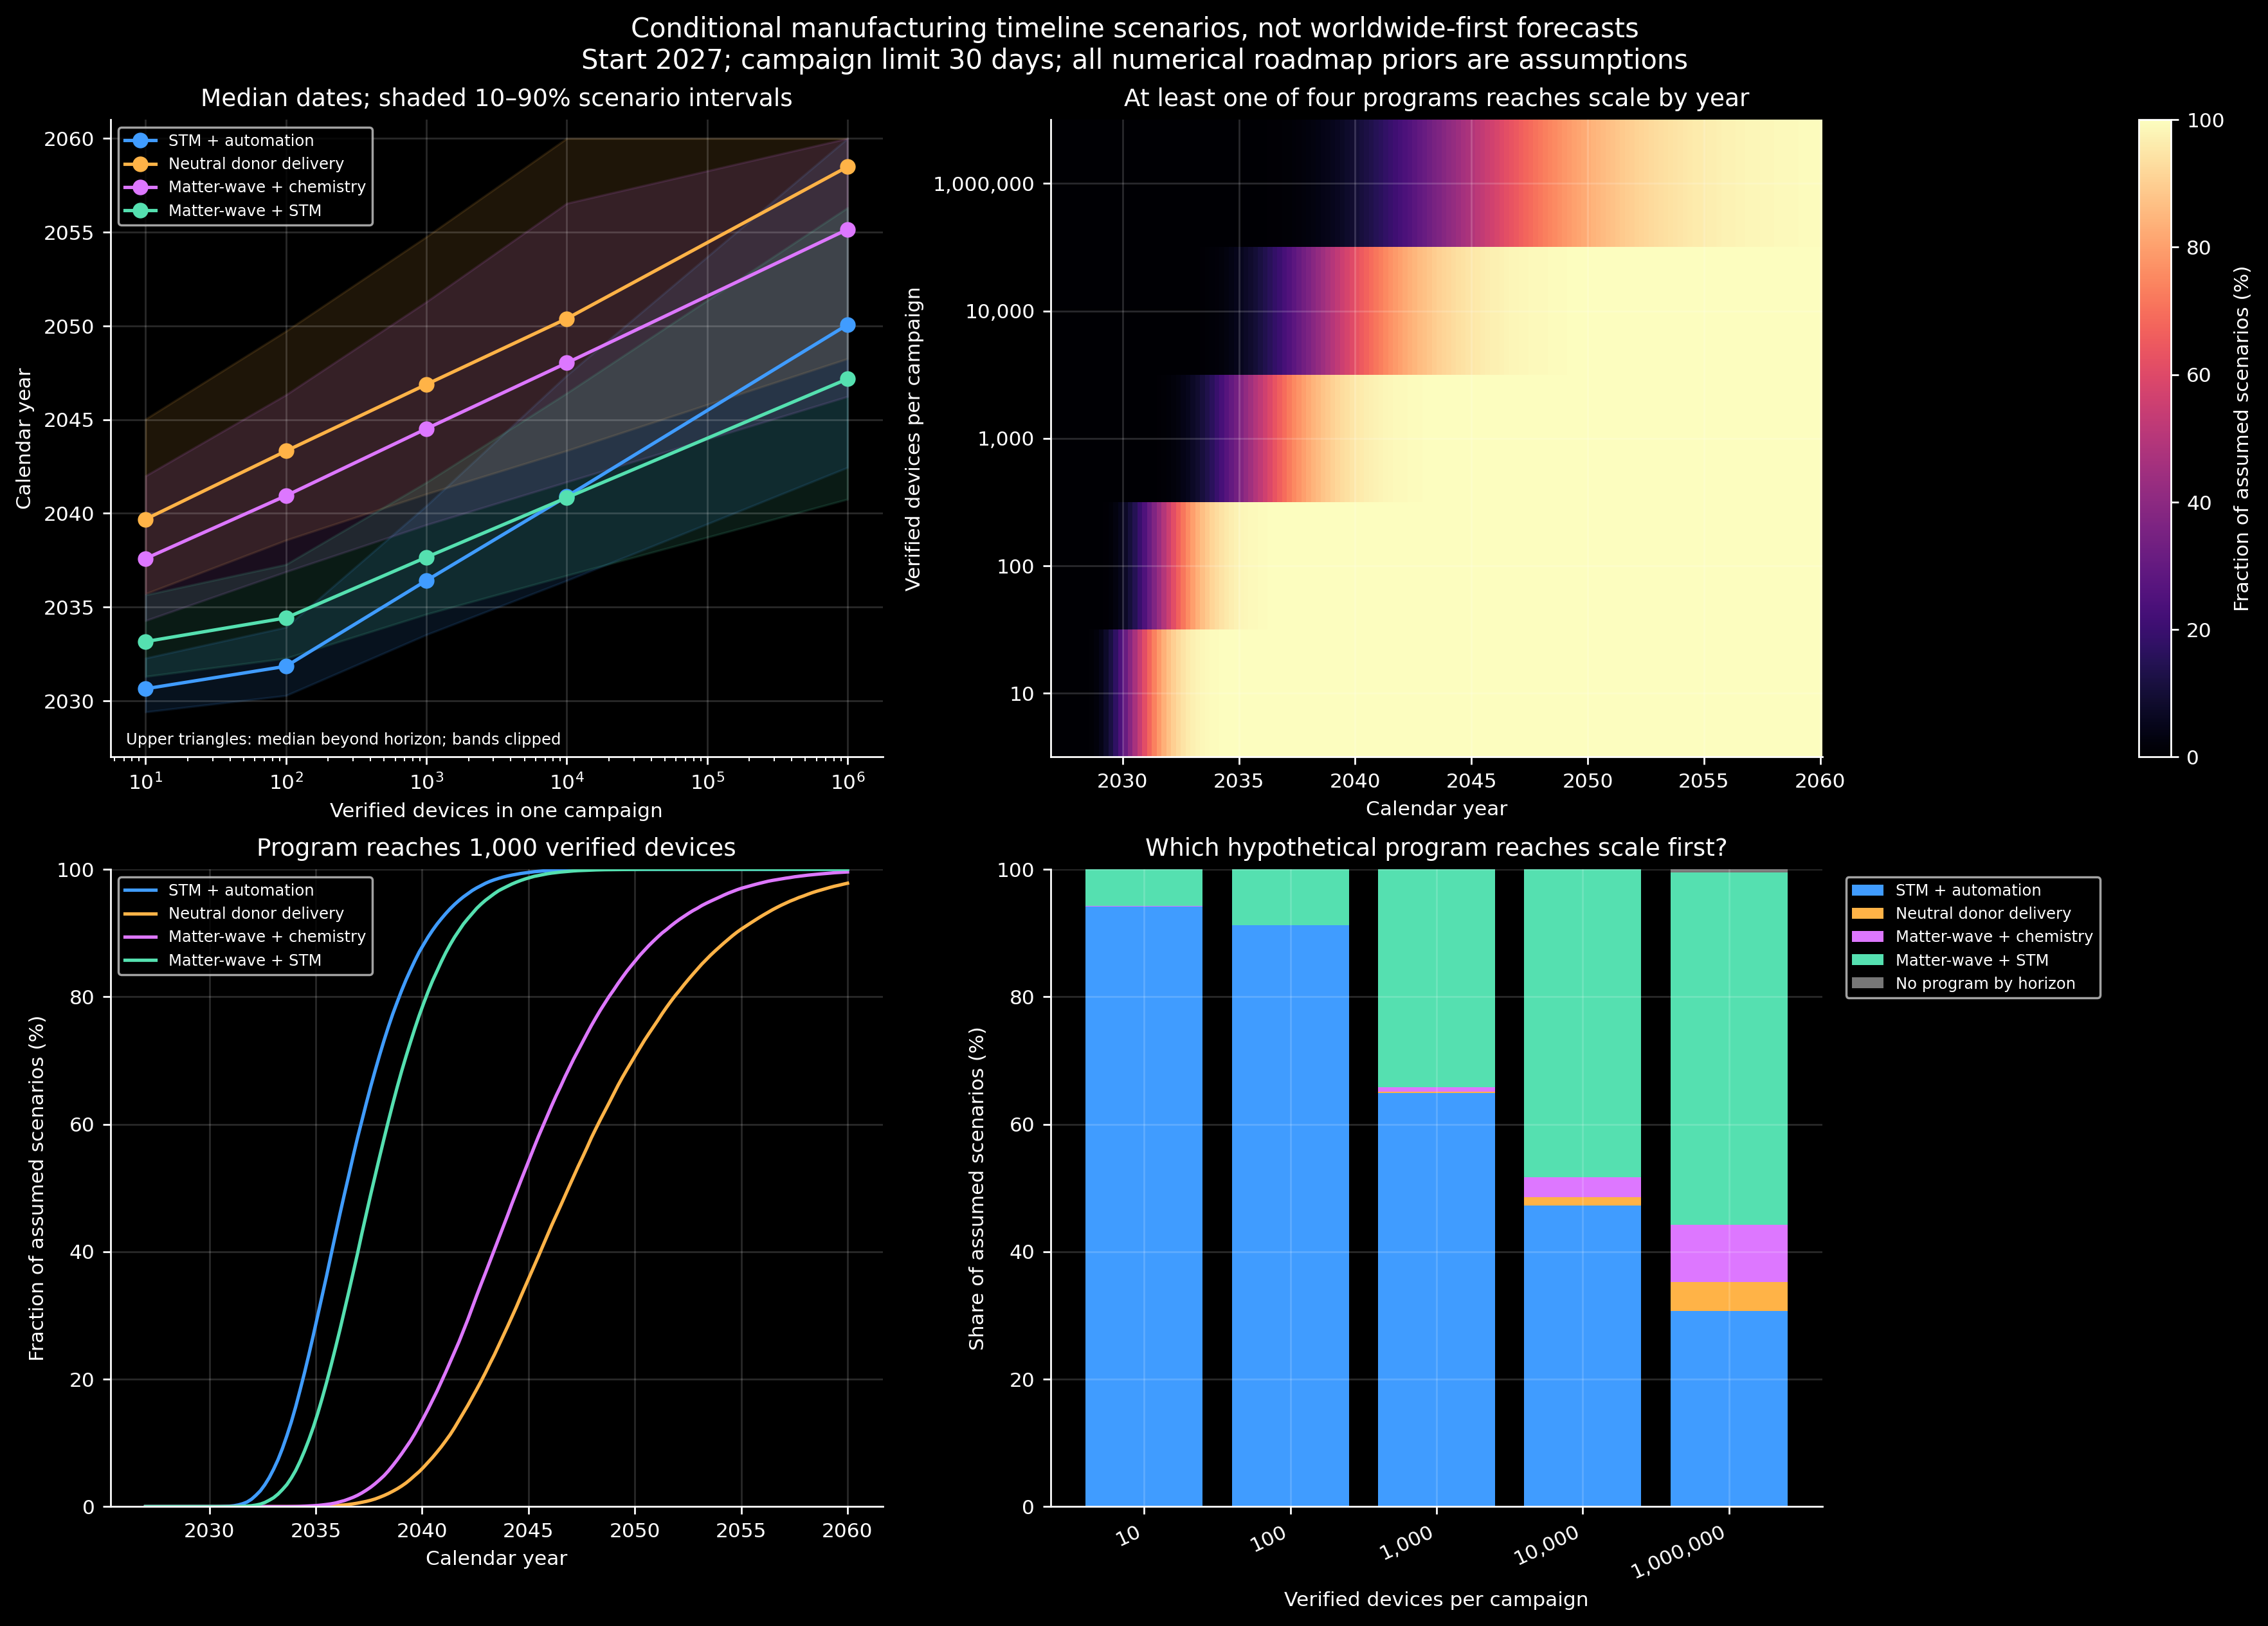


SCENARIO DATES, not evidence-calibrated predictions
None/ > horizon includes unsuccessful or late programs; none are dropped.

STM + automation
          10 devices: P10/ P50/ P90 year = 2029.4/ 2030.6/ 2032.3; by horizon = 100.0%
         100 devices: P10/ P50/ P90 year = 2030.3/ 2031.8/ 2033.9; by horizon = 100.0%
       1,000 devices: P10/ P50/ P90 year = 2033.5/ 2036.4/ 2040.4; by horizon = 100.0%
      10,000 devices: P10/ P50/ P90 year = 2036.4/ 2040.9/ 2047.4; by horizon = 100.0%
   1,000,000 devices: P10/ P50/ P90 year = 2042.4/ 2050.1/ > horizon; by horizon = 87.0%

Neutral donor delivery
          10 devices: P10/ P50/ P90 year = 2035.7/ 2039.7/ 2045.0; by horizon = 100.0%
         100 devices: P10/ P50/ P90 year = 2038.6/ 2043.3/ 2049.7; by horizon = 99.8%
       1,000 devices: P10/ P50/ P90 year = 2041.0/ 2046.9/ 2054.8; by horizon = 97.8%
      10,000 devices: P10/ P50/ P90 year = 2043.3/ 2050.4/ > horizon; by horizon = 89.9%
   1,000,000 devices: P10/ P50/ P90 year = 204

In [7]:
"""Plot GPU Monte Carlo scenarios for future single-atom transistor scale-up.

This cell does not rerun, import, or modify the preceding simulation. All
outputs use TIMELINE_ names. Figures render in memory at 250 DPI.

Interpretation:
    A milestone means at least N individually electrically verified single-P
    transistors within ONE fabrication-and-test campaign of at most 30 days.
    The campaign may span multiple substrates; it is not an N-device connected
    circuit, defect-free chip, sustained factory output, or commercial release.
    Single-donor identity and electrical functionality are assumed verifiable
    without false positives; the effective yield includes both requirements.
    No room-temperature operation or CMOS equivalence is assumed.

    Dates refer to the first such campaign in a hypothetical program starting
    at START_YEAR. They are NOT forecasts of worldwide first demonstrations.
    The deterministically positioned single-P transistor demonstration already
    exists: Fuechsle et al. (2012), doi:10.1038/nnano.2012.21. Smaller/larger
    modern experiments must not be assigned manufacturing yields from atom or
    qubit counts alone. We have not established a worldwide record for each N.

Evidence and limitations:
    NIST's 2025 program describes operator-intensive STM fabrication and ongoing
    automation, supporting the inclusion of process and metrology bottlenecks:
    https://www.nist.gov/programs-projects/
    atom-scale-devices-engineering-metrology-and-manufacturability
    Automation research: doi:10.1021/acsnano.4c00080 (2024).
    EUV H-desorption process: doi:10.1038/s41467-024-44790-6 (2024).
    Matter-wave mask design: doi:10.1103/PhysRevApplied.11.024009 (2019).
    STM incorporation: doi:10.1021/acsnano.2c08162 (2022).

    These sources motivate milestones. NONE supplies the numerical R&D duration,
    capacity doubling, device yield, or program-success priors used here.
    In particular, 12/12 incorporation results do not calibrate calendar dates,
    full-device yield, or manufacturing learning rates. This is an explicitly
    speculative planning scenario, not a literature-fitted technology forecast.
    It cannot support a claim that a particular scale will arrive in a given year.

Stochastic model:
    Tool preparation and atomic-process development run in parallel, followed
    by serial integration/qualification: T_ready=max(T_tool,T_atomic)+T_int.
    A common resource multiplier correlates delays across competing programs.
    Batch capacity C and attempted-device test rate R double after readiness,
    with uncertain doubling times and hard upper limits. Their growth is an
    engineering assumption, not Moore's law extrapolated from historical data.
    Yield is constant within each program trajectory and jointly represents
    exact-one donor identity, placement, integration and electrical operation.

    Required attempted devices A_N follow a negative binomial stopping count.
    Independent increments in target successful devices make nested scale
    milestones consistent. Gamma-Poisson sampling implements the exact count
    distribution on the GPU: failures~Poisson(Gamma(delta_N,(1-p)/p)).
    Trial outcomes are conditionally independent given the shared yield p;
    within-batch spatial defects are not explicitly modeled.

    Required growth time is max(d_C*log2(A_N/C0),
    d_R*log2(A_N/(H*R0)),0), where H is the campaign-hour limit.
    Completion adds A_N/R(t) operating hours converted to calendar years.
    A short one-dimensional minimization allows deliberate waiting for higher
    test rate when this produces earlier completion. The completion envelope
    remains nondecreasing with target scale.

    This earliest-feasible calculation is optimistic: it does not charge for
    failed pilot campaigns, budget overruns outside the resource multiplier,
    or scheduling mistakes. It is not an executable manufacturing schedule.

    Earlier target campaigns are not added as mandatory separate production
    runs: targets describe nested successes in a scale-capable campaign.
    Four parallel, separately resourced hypothetical programs are compared.
    The earliest of four is NOT a model of the number of laboratories worldwide.

    By default, program success and each capacity-step success are conditioned
    to one. Users may enter elicited probabilities; these are not measured odds.
    Failed programs, hard-limit failures, and events beyond the horizon remain
    in denominators. Quantiles are not computed on successful runs alone.
"""

import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# - Control knobs: execution and milestone definition -
TIMELINE_USE_GPU = True
TIMELINE_SEED = 20260925
TIMELINE_DRAWS = 100000
TIMELINE_DPI = 250
TIMELINE_START_YEAR = 2027.0
TIMELINE_HORIZON_YEAR = 2060.0
TIMELINE_SCALES = np.array([10, 100, 1000, 10000, 1000000], dtype=np.int64)
TIMELINE_CAMPAIGN_DAYS = 30.0
TIMELINE_OPERATING_HOURS_PER_DAY = 16.0
TIMELINE_RESOURCE_MULTIPLIER = (0.7, 1.0, 1.5)
TIMELINE_SHOW_PLOTS = True
TIMELINE_SAVE_OUTPUTS = False
TIMELINE_OUTPUT_DIRECTORY = "single_atom_timeline"

# - Control knobs: assumed program priors, not measurements -
# Triples are triangular (minimum, mode, maximum). All units are explicit.
# Effective yield means fully verified devices/ all attempted device sites.
# No previous acceptance-proxy simulation is relabeled as measured functionality.
# Success=1 conditions on eventual technical success, not certainty in reality.
# Initial capacities and rates apply AFTER successful process qualification.
TIMELINE_ROUTES = {
    "STM + automation": {
        "tool_years": (0.25, 1.0, 3.0),
        "atomic_process_years": (0.25, 0.75, 2.0),
        "integration_years": (0.5, 1.5, 4.0),
        "verified_device_yield": (0.20, 0.60, 0.90),
        "initial_attempts_per_campaign": 100.0,
        "initial_attempts_per_hour": (0.5, 10.0, 100.0),
        "capacity_doubling_years": (0.5, 1.0, 2.5),
        "rate_doubling_years": (0.5, 1.0, 2.5),
        "max_attempts_per_campaign": 1e7,
        "max_attempts_per_hour": 1e5,
        "program_success_probability": 1.0,
        "capacity_step_success_probability": 1.0,
    },
    "Neutral donor delivery": {
        "tool_years": (1.0, 3.0, 7.0),
        "atomic_process_years": (2.0, 5.0, 12.0),
        "integration_years": (1.0, 3.0, 8.0),
        "verified_device_yield": (0.0001, 0.01, 0.10),
        "initial_attempts_per_campaign": 100.0,
        "initial_attempts_per_hour": (1.0, 100.0, 1000.0),
        "capacity_doubling_years": (0.3, 0.8, 2.0),
        "rate_doubling_years": (0.3, 0.8, 2.0),
        "max_attempts_per_campaign": 1e8,
        "max_attempts_per_hour": 1e6,
        "program_success_probability": 1.0,
        "capacity_step_success_probability": 1.0,
    },
    "Matter-wave + chemistry": {
        "tool_years": (1.0, 3.0, 7.0),
        "atomic_process_years": (2.0, 4.0, 10.0),
        "integration_years": (1.0, 3.0, 8.0),
        "verified_device_yield": (0.001, 0.03, 0.25),
        "initial_attempts_per_campaign": 100.0,
        "initial_attempts_per_hour": (1.0, 100.0, 1000.0),
        "capacity_doubling_years": (0.3, 0.8, 2.0),
        "rate_doubling_years": (0.3, 0.8, 2.0),
        "max_attempts_per_campaign": 1e8,
        "max_attempts_per_hour": 1e6,
        "program_success_probability": 1.0,
        "capacity_step_success_probability": 1.0,
    },
    "Matter-wave + STM": {
        "tool_years": (1.0, 2.5, 6.0),
        "atomic_process_years": (0.5, 1.5, 4.0),
        "integration_years": (1.0, 2.0, 5.0),
        "verified_device_yield": (0.10, 0.40, 0.80),
        "initial_attempts_per_campaign": 100.0,
        "initial_attempts_per_hour": (0.5, 30.0, 300.0),
        "capacity_doubling_years": (0.3, 0.7, 1.8),
        "rate_doubling_years": (0.3, 0.7, 1.8),
        "max_attempts_per_campaign": 1e8,
        "max_attempts_per_hour": 1e6,
        "program_success_probability": 1.0,
        "capacity_step_success_probability": 1.0,
    },
}
TIMELINE_COLORS = ("#409cff", "#ffb347", "#dd77ff", "#55e0b0")


def timeline_backend():
    """Return the requested backend without silent CPU fallback."""
    if not TIMELINE_USE_GPU:
        print("Explicit CPU validation mode.")
        return np, np.asarray
    try:
        import cupy as cp  # pylint: disable=import-outside-toplevel
        cp.zeros(1).sum().item()
        print("GPU:", cp.cuda.runtime.getDeviceProperties(0)["name"])
        return cp, cp.asnumpy
    except Exception as exc:
        raise RuntimeError(
            "Select a GPU runtime and install CuPy first.") from exc


def timeline_validate():
    """Check scenario sizes, units, probabilities and triangular bounds."""
    if not isinstance(TIMELINE_DRAWS, int) or TIMELINE_DRAWS < 1000:
        raise ValueError("Use at least 1000 Monte Carlo trajectories.")
    if TIMELINE_HORIZON_YEAR <= TIMELINE_START_YEAR:
        raise ValueError("Horizon must follow the program start.")
    if (TIMELINE_SCALES.ndim != 1 or len(TIMELINE_SCALES) < 2 or
            not np.issubdtype(TIMELINE_SCALES.dtype, np.integer) or
            np.any(TIMELINE_SCALES <= 0) or
            np.any(np.diff(TIMELINE_SCALES) <= 0)):
        raise ValueError("Scales must be increasing positive integer counts.")
    if (TIMELINE_CAMPAIGN_DAYS <= 0 or
            not 0 < TIMELINE_OPERATING_HOURS_PER_DAY <= 24):
        raise ValueError("Campaign duration and operating hours are invalid.")
    low, mode, high = TIMELINE_RESOURCE_MULTIPLIER
    if not 0 < low <= mode <= high:
        raise ValueError("Resource multiplier bounds must be positive.")
    for route in TIMELINE_ROUTES.values():
        for key, value in route.items():
            if isinstance(value,
                          tuple) and not 0 < value[0] <= value[1] <= value[2]:
                raise ValueError(f"Invalid positive triangular bounds: {key}.")
            if key.endswith("probability") and not 0 <= value <= 1:
                raise ValueError(f"Invalid probability: {key}.")
        if route["verified_device_yield"][2] > 1:
            raise ValueError("Yield exceeds one.")
        if not 0 < route["initial_attempts_per_campaign"] <= route[
                "max_attempts_per_campaign"]:
            raise ValueError("Invalid campaign capacity limits.")
        if route["initial_attempts_per_hour"][2] > route[
                "max_attempts_per_hour"]:
            raise ValueError("Initial rate exceeds the maximum.")
    if TIMELINE_ROUTES["Neutral donor delivery"]["verified_device_yield"][
            2] > 1/ np.e:
        raise ValueError(
            "Unheralded Poisson exact-one yield cannot exceed 1/e.")


def timeline_triangular(rng, bounds):
    """Draw one positive assumed parameter for each program trajectory."""
    low, mode, high = bounds
    if low == high:
        return rng.uniform(low, low, size=TIMELINE_DRAWS)
    return rng.triangular(low, mode, high, size=TIMELINE_DRAWS)


def timeline_simulate(xp, to_host):
    """Generate nested milestone dates for four hypothetical parallel programs.

    Args:
        xp: CuPy or explicitly selected NumPy module.
        to_host: Function converting backend arrays to host NumPy.

    Returns:
        Mapping of route names to host arrays containing uncensored dates,
        attempted-device counts, and effective verified-device yields.
    """
    rng = xp.random.RandomState(TIMELINE_SEED)
    resource = timeline_triangular(rng, TIMELINE_RESOURCE_MULTIPLIER)
    hours_per_year = 365.25 * TIMELINE_OPERATING_HOURS_PER_DAY
    max_hours = TIMELINE_CAMPAIGN_DAYS * TIMELINE_OPERATING_HOURS_PER_DAY
    results = {}
    for name, route in TIMELINE_ROUTES.items():
        tool = timeline_triangular(rng, route["tool_years"])
        atomic = timeline_triangular(rng, route["atomic_process_years"])
        integrate = timeline_triangular(rng, route["integration_years"])
        ready = resource * (xp.maximum(tool, atomic) + integrate)
        yield_probability = timeline_triangular(rng,
                                                route["verified_device_yield"])
        capacity_doubling = resource * timeline_triangular(
            rng, route["capacity_doubling_years"])
        rate_doubling = resource * timeline_triangular(
            rng, route["rate_doubling_years"])
        initial_rate = timeline_triangular(rng,
                                           route["initial_attempts_per_hour"])
        attempts = xp.zeros(TIMELINE_DRAWS, dtype=xp.int64)
        alive = rng.random_sample(
            TIMELINE_DRAWS) < route["program_success_probability"]
        # A shared U gives P(survive k capacity steps)=p_step**k and ensures
        # that a program that fails a lower-scale hurdle cannot recover later.
        step_uniform = rng.random_sample(TIMELINE_DRAWS)
        dates = []
        attempt_history = []
        previous_target = 0
        previous_finish = xp.zeros(TIMELINE_DRAWS)
        for target in TIMELINE_SCALES:
            increment = int(target - previous_target)
            poisson_mean = rng.gamma(increment, (1 - yield_probability)/
                                     yield_probability)
            attempts += increment + rng.poisson(poisson_mean)
            needed_capacity_doublings = xp.maximum(
                0, xp.log2(attempts/ route["initial_attempts_per_campaign"]))
            needed_rate_doublings = xp.maximum(
                0, xp.log2(attempts/ (max_hours * initial_rate)))
            minimum_wait = xp.maximum(
                capacity_doubling * needed_capacity_doublings,
                rate_doubling * needed_rate_doublings)
            # Minimize wait + production duration. Before the rate cap,
            # derivative zero occurs when duration = d_rate/ln(2) years.
            optimum_wait = rate_doubling * xp.log2(
                attempts * np.log(2)/
                (initial_rate * hours_per_year * rate_doubling))
            cap_wait = rate_doubling * xp.log2(
                route["max_attempts_per_hour"]/ initial_rate)
            wait = xp.maximum(minimum_wait, xp.minimum(optimum_wait, cap_wait))
            rate = initial_rate * xp.exp2(
                xp.minimum(
                    wait/ rate_doubling,
                    xp.log2(route["max_attempts_per_hour"]/ initial_rate)))
            campaign_hours = attempts/ rate
            viable = (attempts <= route["max_attempts_per_campaign"])
            viable &= campaign_hours <= max_hours * (1 + 1e-10)
            steps = xp.ceil(needed_capacity_doublings)
            alive &= step_uniform < route[
                "capacity_step_success_probability"]**steps
            finish = ready + wait + campaign_hours/ hours_per_year
            finish = xp.maximum(finish, previous_finish)
            finish = xp.where(alive & viable, finish, xp.inf)
            dates.append(to_host(TIMELINE_START_YEAR + finish))
            attempt_history.append(to_host(attempts.copy()))
            previous_target = int(target)
            previous_finish = finish
        results[name] = {
            "year": np.stack(dates, axis=1),
            "attempts": np.stack(attempt_history, axis=1),
            "yield": to_host(yield_probability)
        }
        print(f"Simulated {name}: {TIMELINE_DRAWS:,} trajectories.")
    return results


def timeline_sampler_check(xp):
    """Check the GPU stopping-count sampler against negative-binomial moments."""
    rng = xp.random.RandomState(TIMELINE_SEED + 91)
    sample_count = 50000
    successes = 10
    probability = 0.4
    mean = rng.gamma(successes, (1 - probability)/ probability,
                     size=sample_count)
    count = successes + rng.poisson(mean)
    expected_mean = successes/ probability
    expected_variance = successes * (1 - probability)/ probability**2
    error = abs(float(count.mean().item()) - expected_mean)
    if error > 7 * np.sqrt(expected_variance/ sample_count):
        raise AssertionError("Stopping-count sampler mean check failed.")
    if not np.isclose(float(count.var().item()), expected_variance, rtol=0.08):
        raise AssertionError("Stopping-count sampler variance check failed.")
    print("Negative-binomial stopping-count sampler checks passed.")


def timeline_quantiles(values, probabilities=(0.1, 0.5, 0.9)):
    """Return empirical inverse-CDF quantiles retaining failures and censoring."""
    censored = np.where(values <= TIMELINE_HORIZON_YEAR, values, np.inf)
    ordered = np.sort(censored, axis=0)
    indices = np.ceil(np.asarray(probabilities) * len(values)).astype(int) - 1
    return ordered[np.clip(indices, 0, len(values) - 1)]


def timeline_plot(results):
    """Plot timeline bands, horizon probabilities and earliest-route scenarios.

    Args:
        results: Mapping returned by timeline_simulate.

    Returns:
        PNG bytes and a JSON-serializable scenario summary.
    """
    plt.style.use("dark_background")
    plt.rcParams.update({
        "figure.dpi": TIMELINE_DPI,
        "savefig.dpi": TIMELINE_DPI,
        "font.size": 9
    })
    years = np.linspace(TIMELINE_START_YEAR, TIMELINE_HORIZON_YEAR, 160)
    scales = TIMELINE_SCALES
    labels = [f"{int(value):,}" for value in scales]
    all_years = np.stack([data["year"] for data in results.values()])
    earliest = all_years.min(axis=0)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
    summary = {}
    for color, (name, data) in zip(TIMELINE_COLORS, results.items()):
        q = timeline_quantiles(data["year"])
        # Do not replace missing medians with a fabricated horizon date.
        axes[0, 0].plot(scales,
                        np.where(np.isfinite(q[1]), q[1], np.nan),
                        color=color,
                        marker="o",
                        label=name)
        axes[0, 0].fill_between(scales,
                                np.minimum(q[0], TIMELINE_HORIZON_YEAR),
                                np.minimum(q[2], TIMELINE_HORIZON_YEAR),
                                color=color,
                                alpha=0.12)
        missing = ~np.isfinite(q[1])
        axes[0, 0].scatter(scales[missing],
                           np.full(missing.sum(), TIMELINE_HORIZON_YEAR),
                           marker="^",
                           color=color)
        summary[name] = {
            "quantile_years_10_50_90": [
                [float(v) if np.isfinite(v) else None for v in row] for row in q
            ],
            "probability_by_horizon":
                np.mean(data["year"] <= TIMELINE_HORIZON_YEAR, axis=0).tolist(),
        }
    axes[0, 0].set(xscale="log",
                   xlabel="Verified devices in one campaign",
                   ylabel="Calendar year",
                   ylim=(TIMELINE_START_YEAR, TIMELINE_HORIZON_YEAR + 1),
                   title="Median dates; shaded 10–90% scenario intervals")
    axes[0, 0].legend(fontsize=7, loc="upper left")
    axes[0, 0].text(0.02,
                    0.02,
                    "Upper triangles: median beyond horizon; bands clipped",
                    transform=axes[0, 0].transAxes,
                    fontsize=7)
    cumulative = np.stack([
        np.mean(earliest[:, i, None] <= years[None, :], axis=0)
        for i in range(len(scales))
    ])
    mesh = axes[0, 1].pcolormesh(years,
                                 np.arange(len(scales)),
                                 100 * cumulative,
                                 shading="auto",
                                 cmap="magma",
                                 vmin=0,
                                 vmax=100)
    axes[0, 1].set_yticks(range(len(scales)), labels)
    axes[0, 1].set(xlabel="Calendar year",
                   ylabel="Verified devices per campaign",
                   title="At least one of four programs reaches scale by year")
    fig.colorbar(mesh, ax=axes[0, 1], label="Fraction of assumed scenarios (%)")
    selected = min(range(len(scales)),
                   key=lambda i: abs(np.log10(scales[i]) - 3))
    for color, (name, data) in zip(TIMELINE_COLORS, results.items()):
        cdf = np.mean(data["year"][:, selected, None] <= years[None, :], axis=0)
        axes[1, 0].plot(years, 100 * cdf, color=color, label=name)
    axes[1, 0].set(xlabel="Calendar year",
                   ylabel="Fraction of assumed scenarios (%)",
                   ylim=(0, 100),
                   title=f"Program reaches {labels[selected]} verified devices")
    axes[1, 0].legend(fontsize=7)
    # Rank only finite, in-horizon first milestones. Ties split their mass.
    arrived = earliest <= TIMELINE_HORIZON_YEAR
    tied = (all_years == earliest[None, :, :]) & arrived[None, :, :]
    shares = (tied/ np.maximum(tied.sum(axis=0), 1)[None, :, :]).mean(axis=1)
    none = 1 - arrived.mean(axis=0)
    assert np.allclose(shares.sum(axis=0) + none, 1)
    bottom = np.zeros(len(scales))
    for color, name, share in zip(TIMELINE_COLORS, results, shares):
        axes[1, 1].bar(np.arange(len(scales)),
                       100 * share,
                       bottom=100 * bottom,
                       color=color,
                       label=name)
        bottom += share
    axes[1, 1].bar(np.arange(len(scales)),
                   100 * none,
                   bottom=100 * bottom,
                   color="#777777",
                   label="No program by horizon")
    axes[1, 1].set_xticks(range(len(scales)), labels, rotation=25, ha="right")
    axes[1, 1].set(ylabel="Share of assumed scenarios (%)",
                   ylim=(0, 100),
                   xlabel="Verified devices per campaign",
                   title="Which hypothetical program reaches scale first?")
    axes[1, 1].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))
    fig.suptitle(
        "Conditional manufacturing timeline scenarios, not worldwide-first forecasts\n"
        f"Start {TIMELINE_START_YEAR:g}; campaign limit {TIMELINE_CAMPAIGN_DAYS:g} days; "
        "all numerical roadmap priors are assumptions",
        fontsize=12)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=TIMELINE_DPI, bbox_inches="tight")
    if TIMELINE_SHOW_PLOTS:
        plt.show()
    plt.close(fig)
    print("\nSCENARIO DATES, not evidence-calibrated predictions")
    print(
        "None/ > horizon includes unsuccessful or late programs; none are dropped."
    )
    for name, data in summary.items():
        print("\n" + name)
        for i, scale in enumerate(labels):
            dates = [data["quantile_years_10_50_90"][j][i] for j in range(3)]
            rendered = "/ ".join(
                f"{date:.1f}" if date is not None else "> horizon"
                for date in dates)
            print(f"  {scale:>10s} devices: P10/ P50/ P90 year = {rendered}; "
                  f"by horizon = {data['probability_by_horizon'][i]:.1%}")
    return buffer.getvalue(), summary


def timeline_main():
    """Run the standalone GPU scenario cell and return its reusable results."""
    timeline_validate()
    xp, to_host = timeline_backend()
    timeline_sampler_check(xp)
    results = timeline_simulate(xp, to_host)
    for data in results.values():
        assert np.all(data["year"][:, 1:] >= data["year"][:, :-1])
        assert np.all(data["attempts"] >= TIMELINE_SCALES[None, :])
    png, summary = timeline_plot(results)
    if TIMELINE_SAVE_OUTPUTS:
        directory = Path(TIMELINE_OUTPUT_DIRECTORY)
        directory.mkdir(parents=True, exist_ok=True)
        (directory/ "manufacturing_timeline.png").write_bytes(png)
        metadata = {
            "seed": TIMELINE_SEED,
            "draws": TIMELINE_DRAWS,
            "start_year": TIMELINE_START_YEAR,
            "horizon_year": TIMELINE_HORIZON_YEAR,
            "scales": TIMELINE_SCALES.tolist(),
            "campaign_days": TIMELINE_CAMPAIGN_DAYS,
            "operating_hours_per_day": TIMELINE_OPERATING_HOURS_PER_DAY,
            "resource_multiplier": TIMELINE_RESOURCE_MULTIPLIER,
            "routes": TIMELINE_ROUTES,
            "summary": summary
        }
        (directory/ "timeline_assumptions_and_results.json").write_text(
            json.dumps(metadata, indent=2, allow_nan=False), encoding="utf-8")
    print(
        "\nKnown single-P transistor anchor: 2012. No global-first dates inferred."
    )
    return results, summary, png


if __name__ == "__main__":
    TIMELINE_RESULTS, TIMELINE_SUMMARY, TIMELINE_PNG = timeline_main()